In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import matplotlib.font_manager as fm
import geopandas as gpd
import folium
from matplotlib import cm
from matplotlib.colors import Normalize

# 한글 폰트 설정 (macOS의 경우 AppleGothic)
plt.rc('font', family='AppleGothic')

# 마이너스 기호가 깨지는 문제 해결
plt.rcParams['axes.unicode_minus'] = False

sns.set_theme(
    style="whitegrid",
    context="talk",
    font="AppleGothic"
)

plt.rcParams["axes.unicode_minus"] = False

print(plt.rcParams["font.family"])
print('로드 완료')

['AppleGothic']


### **Temp**
| 컬럼      | 설명                       |
| ------- | ------------------------ |
| gu      | 시군구                      |
| year    | 연도                       |
| month   | 월                        |
| ta_mean | 평균기온(℃)                  |
| ta_min  | 최저기온(℃)                  |
| ta_max  | 최고기온(℃)                  |
| hm_mean | 평균습도(%)                  |
| ws_mean | 평균풍속(m/s)                |
| cdd     | 냉방도일(Cooling Degree Day) |
| hdd     | 난방도일(Heating Degree Day) |
| thi     | 불쾌지수                     |


### **ONI**
| 컬럼    | 설명                 |
| ----- | ------------------ |
| year  | 연도                 |
| month | 월                  |
| oni   | Oceanic Niño Index |


In [196]:
ROOT = Path.cwd().parents[1]
DATA_OUTPUT = ROOT / "data" / "output"
SAVE = ROOT / "data" / "output"

kepco = pd.read_csv(DATA_OUTPUT / "kepco_mapping_final_20052026.csv")
temp = pd.read_csv(DATA_OUTPUT / "temperature_gu_monthly.csv")
oni = pd.read_csv(DATA_OUTPUT / 'oni_monthly.csv')
gu_geo = gpd.read_file("../../data/file/shp/bnd_sigungu_11_2025_2Q.shp")

display(temp.head())
display(kepco.head())
display(oni.head())

,gu,year,month,ta_mean,ta_min,ta_max,hm_mean,ws_mean,cdd,hdd,thi
0,강남구,2005,1,-0.193,-8.508,9.292,54.80,2.348,0.00,563.99,38.202
1,강남구,2005,2,-0.334,-11.471,11.729,53.89,2.525,0.00,513.37,38.144
2,강남구,2005,3,5.639,-4.840,18.560,54.08,2.719,0.00,383.21,46.153
3,강남구,2005,4,14.627,5.584,31.184,54.40,2.730,0.75,112.42,58.247
4,강남구,2005,5,19.381,8.056,31.756,58.56,2.517,1.25,21.98,64.861


,year,month,sigungu,usage_type,building_type,power_mwh,usage_ratio,capacity_mw,peak_mw,reserve_mw,reserve_rate,reduction_need_score
0,2005,1,강남구,가로등,NaN,3177.0,0.891,54983,49683,5300,10.7,0.000000
1,2005,1,강남구,교육용,교육연구시설,1819.0,0.510,54983,49683,5300,10.7,0.374963
2,2005,1,강남구,농사용,NaN,407.0,0.114,54983,49683,5300,10.7,0.000000
3,2005,1,강남구,산업용,공장,18064.0,5.064,54983,49683,5300,10.7,4.964215
4,2005,1,강남구,산업용,창고시설,18064.0,5.064,54983,49683,5300,10.7,5.584742


,year,month,oni
0,1950,1,-1.53
1,1950,2,-1.34
2,1950,3,-1.16
3,1950,4,-1.18
4,1950,5,-1.07


# 데이터 기본 정보 확인

각 데이터의 행과 열 개수, 컬럼명, 결측치 개수를 확인한다.  
EDA 전에 데이터 구조와 결측 여부를 파악하기 위한 단계이다.

result: building_type 제외 결측 없음

In [19]:
print("kepco shape:", kepco.shape)
print("temp shape:", temp.shape)
print("oni shape:", oni.shape)

print("\n[kepco null]")
display(kepco.isnull().sum())

print("\n[temp null]")
display(temp.isnull().sum())

print("\n[oni null]")
display(oni.isnull().sum())

kepco shape: (244829, 12)
temp shape: (6275, 11)
oni shape: (913, 3)

[kepco null]


year                        0
month                       0
sigungu                     0
usage_type                  0
building_type           25538
power_mwh                   0
usage_ratio                 0
capacity_mw                 0
peak_mw                     0
reserve_mw                  0
reserve_rate                0
reduction_need_score        0
dtype: int64


[temp null]


gu         0
year       0
month      0
ta_mean    0
ta_min     0
ta_max     0
hm_mean    0
ws_mean    0
cdd        0
hdd        0
thi        0
dtype: int64


[oni null]


year     0
month    0
oni      0
dtype: int64

# 기후 데이터 EDA

### 월별 기후 추세
서울 25개 자치구의 월별 기후 데이터를 이용하여

- 평균기온
- 습도
- 풍속
- 냉방도일(CDD)
- 난방도일(HDD)
- 불쾌지수(THI)

의 시공간적 특성을 분석한다.

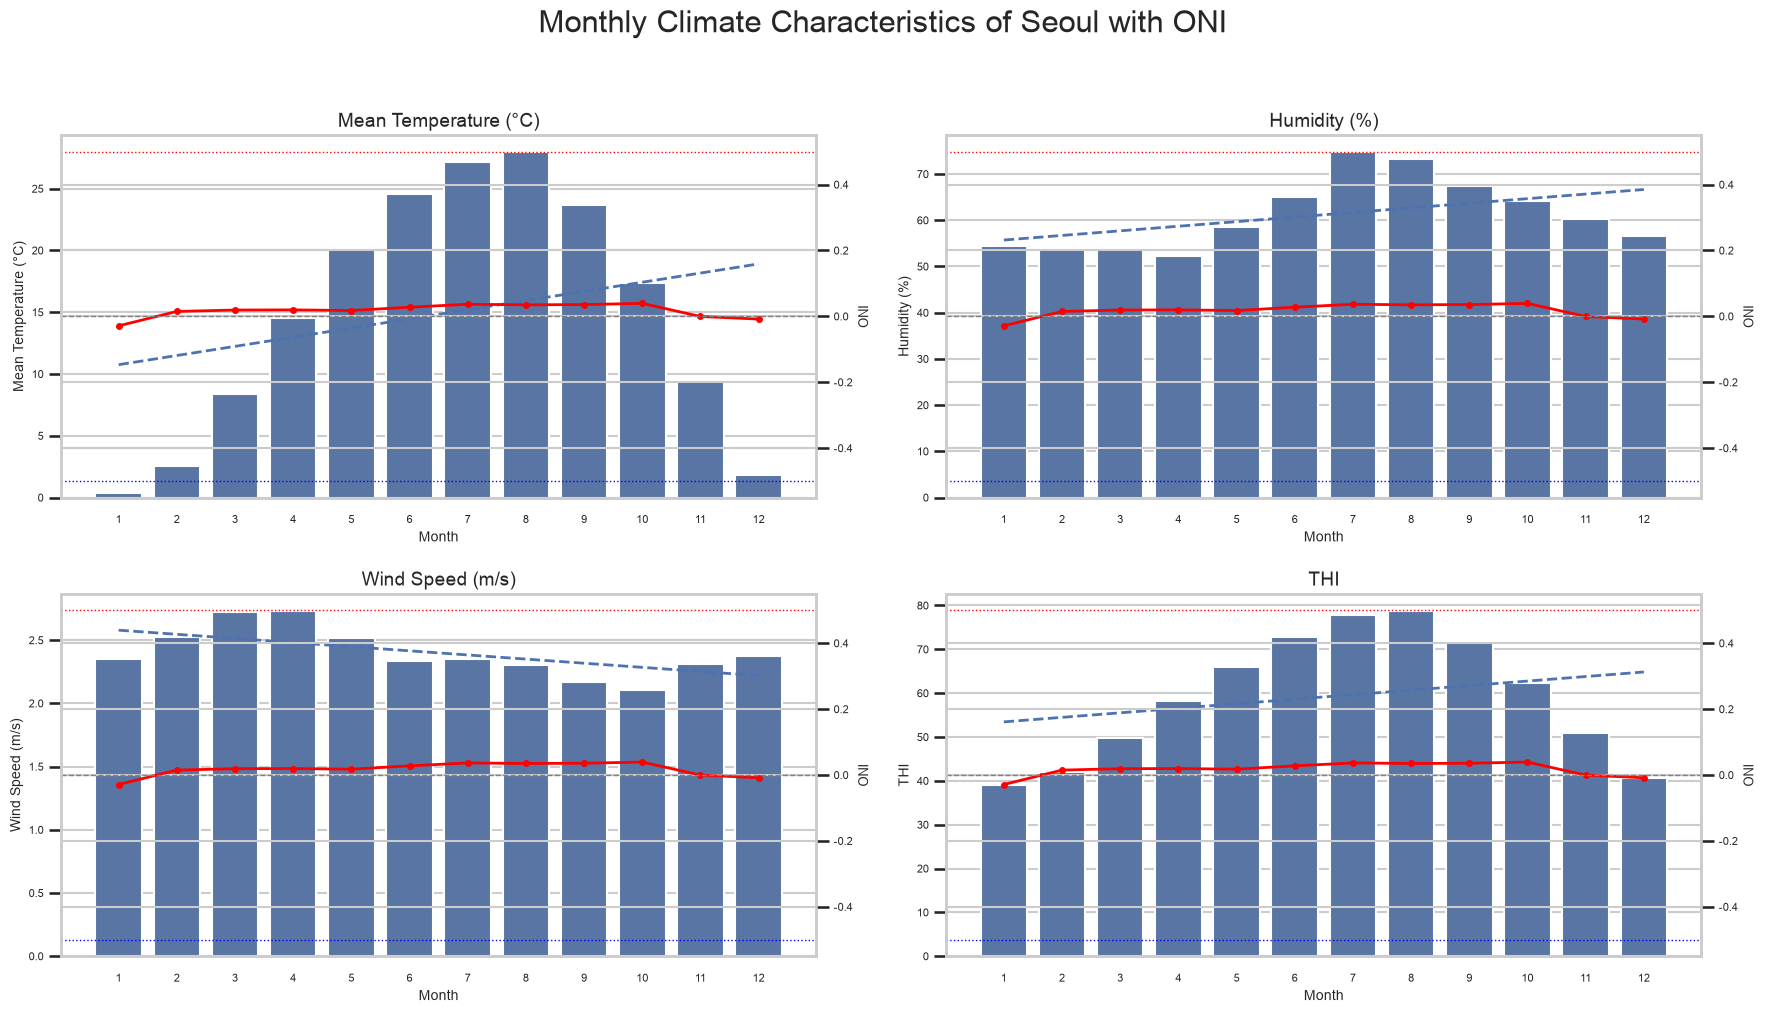

In [63]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(
    style="whitegrid",
    context="talk"
)

# =========================
# 월별 기후 평균
# =========================
monthly = (
    temp
    .groupby("month")
    [
        [
            "ta_mean",
            "hm_mean",
            "ws_mean",
            "thi"
        ]
    ]
    .mean()
    .reset_index()
)

# =========================
# 월별 ONI 평균
# =========================
oni_monthly = (
    oni
    .groupby("month", as_index=False)["oni"]
    .mean()
)

# =========================
# 변수 설정
# =========================
variables = [
    ("ta_mean", "Mean Temperature (°C)"),
    ("hm_mean", "Humidity (%)"),
    ("ws_mean", "Wind Speed (m/s)"),
    ("thi", "THI")
]

# =========================
# 시각화
# =========================
fig, axes = plt.subplots(
    2, 2,
    figsize=(18, 10)
)

for ax, (col, title) in zip(
    axes.flat,
    variables
):

    # 기후 변수 막대그래프
    sns.barplot(
        data=monthly,
        x="month",
        y=col,
        ax=ax
    )

    # 기후 변수 추세선
    z = np.polyfit(
        monthly["month"],
        monthly[col],
        1
    )

    p = np.poly1d(z)

    ax.plot(
        range(len(monthly)),
        p(monthly["month"]),
        "--",
        linewidth=2
    )

    ax.set_title(title, fontsize=14)
    ax.set_xlabel("Month", fontsize=10)
    ax.set_ylabel(title, fontsize=10)

    ax.tick_params(axis="x", labelsize=8)
    ax.tick_params(axis="y", labelsize=8)

    # =========================
    # ONI 추가
    # =========================
    ax2 = ax.twinx()

    ax2.plot(
        range(len(oni_monthly)),
        oni_monthly["oni"],
        color="red",
        marker="o",
        linewidth=2,
        markersize=4
    )

    ax2.axhline(
        0,
        color="gray",
        linestyle="--",
        linewidth=1
    )

    ax2.axhline(
        0.5,
        color="red",
        linestyle=":",
        linewidth=1
    )

    ax2.axhline(
        -0.5,
        color="blue",
        linestyle=":",
        linewidth=1
    )

    ax2.set_ylabel("ONI", fontsize=9)
    ax2.tick_params(axis="y", labelsize=8)

plt.suptitle(
    "Monthly Climate Characteristics of Seoul with ONI",
    fontsize=22,
    y=1.02
)

plt.tight_layout()
plt.show()

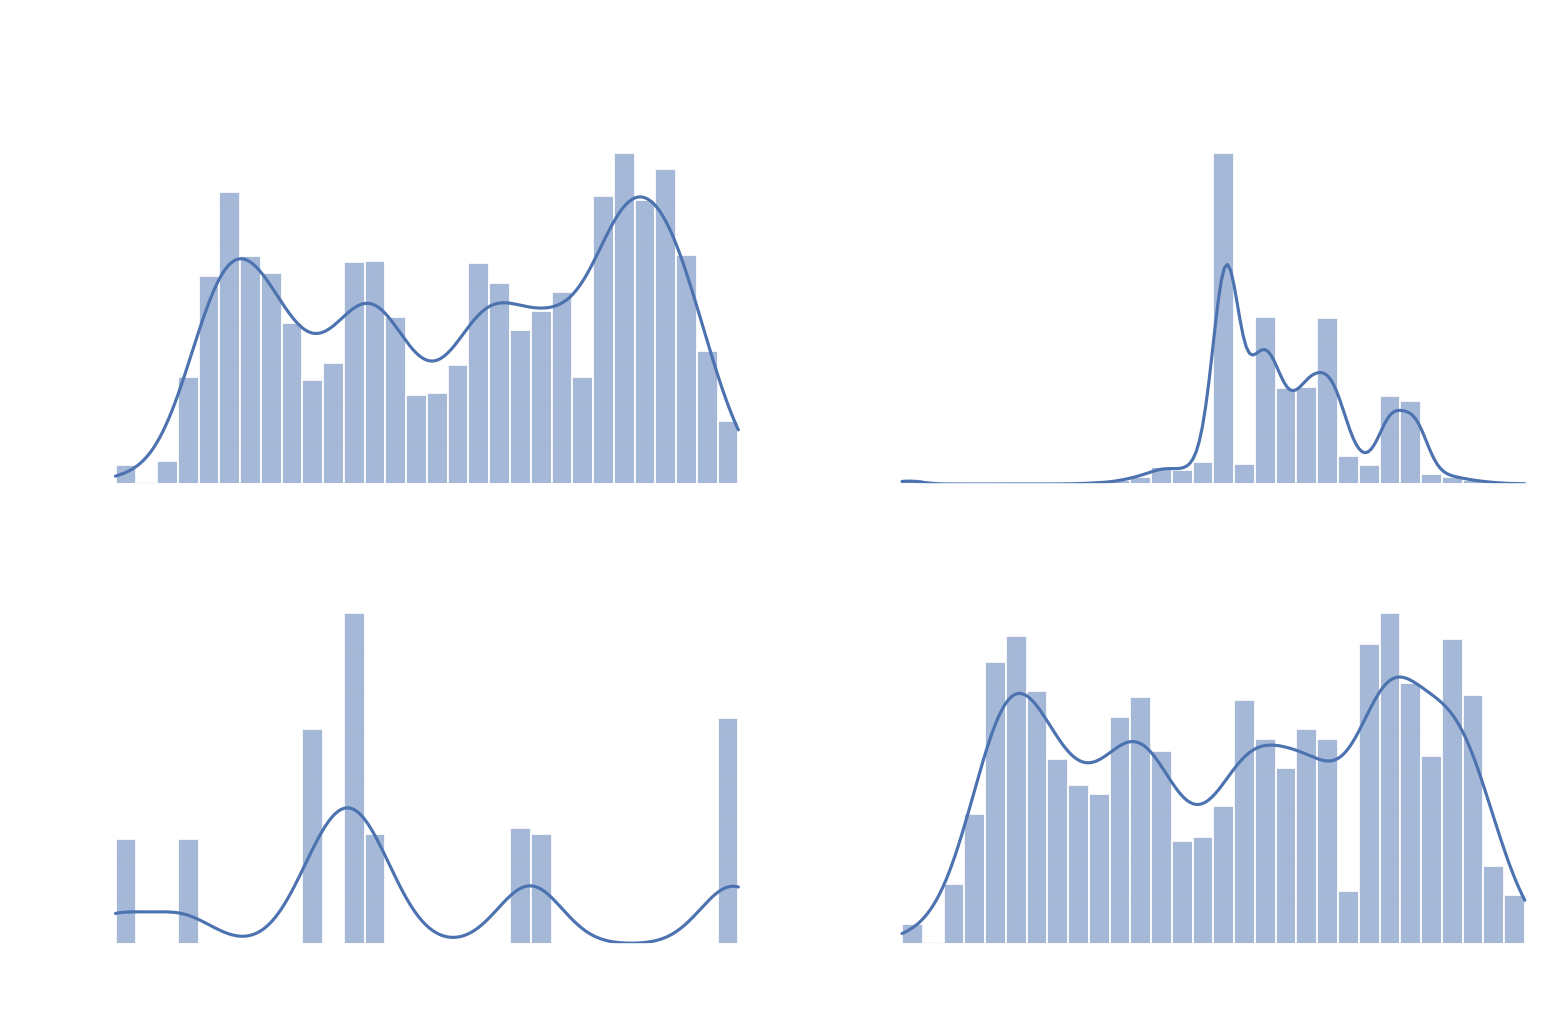

In [236]:
import matplotlib.pyplot as plt
import seaborn as sns

# =====================
# 흰색 테마
# =====================
plt.rcParams["font.family"] = "AppleGothic"
plt.rcParams["axes.unicode_minus"] = False

plt.rcParams.update({
    "text.color": "white",
    "axes.labelcolor": "white",
    "xtick.color": "white",
    "ytick.color": "white",
    "axes.edgecolor": "white"
})

sns.set_theme(
    style="whitegrid",
    context="talk"
)

variables = [
    ("ta_mean", "Mean Temperature (°C)"),
    ("hm_mean", "Humidity (%)"),
    ("ws_mean", "Wind Speed (m/s)"),
    ("thi", "THI")
]

fig, axes = plt.subplots(
    2, 2,
    figsize=(16, 10),
    facecolor="none"
)

# Figure 배경 투명
fig.patch.set_alpha(0)

for ax, (col, title) in zip(
    axes.flat,
    variables
):

    # 축 배경 투명
    ax.set_facecolor("none")

    sns.histplot(
        data=temp,
        x=col,
        bins=30,
        kde=True,
        color="#4C72B0",
        ax=ax
    )

    ax.set_title(
        title,
        color="white",
        fontweight="bold"
    )

    ax.set_xlabel(
        title,
        color="white"
    )

    ax.set_ylabel(
        "Frequency",
        color="white"
    )

    # 축 스타일
    ax.tick_params(
        axis="both",
        colors="white",
        labelsize=9
    )

    ax.grid(
        color="white",
        alpha=0.25,
        linewidth=0.8
    )

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.spines["left"].set_color("white")
    ax.spines["bottom"].set_color("white")

# =====================
# 전체 제목
# =====================
fig.suptitle(
    "Distribution of Climate Variables",
    fontsize=20,
    fontweight="bold",
    color="white",
    y=1.02
)

plt.tight_layout()

plt.savefig(
    SAVE / "chart1.png",
    dpi=300,
    bbox_inches="tight",
    transparent=True
)

plt.show()

### 연도별 기후 변화

2005~2026년 동안 서울시 평균 기후 변화를 확인한다.

장기 추세를 통해 기후변화에 따른
온도 상승 및 냉·난방 수요 변화를 파악할 수 있다.

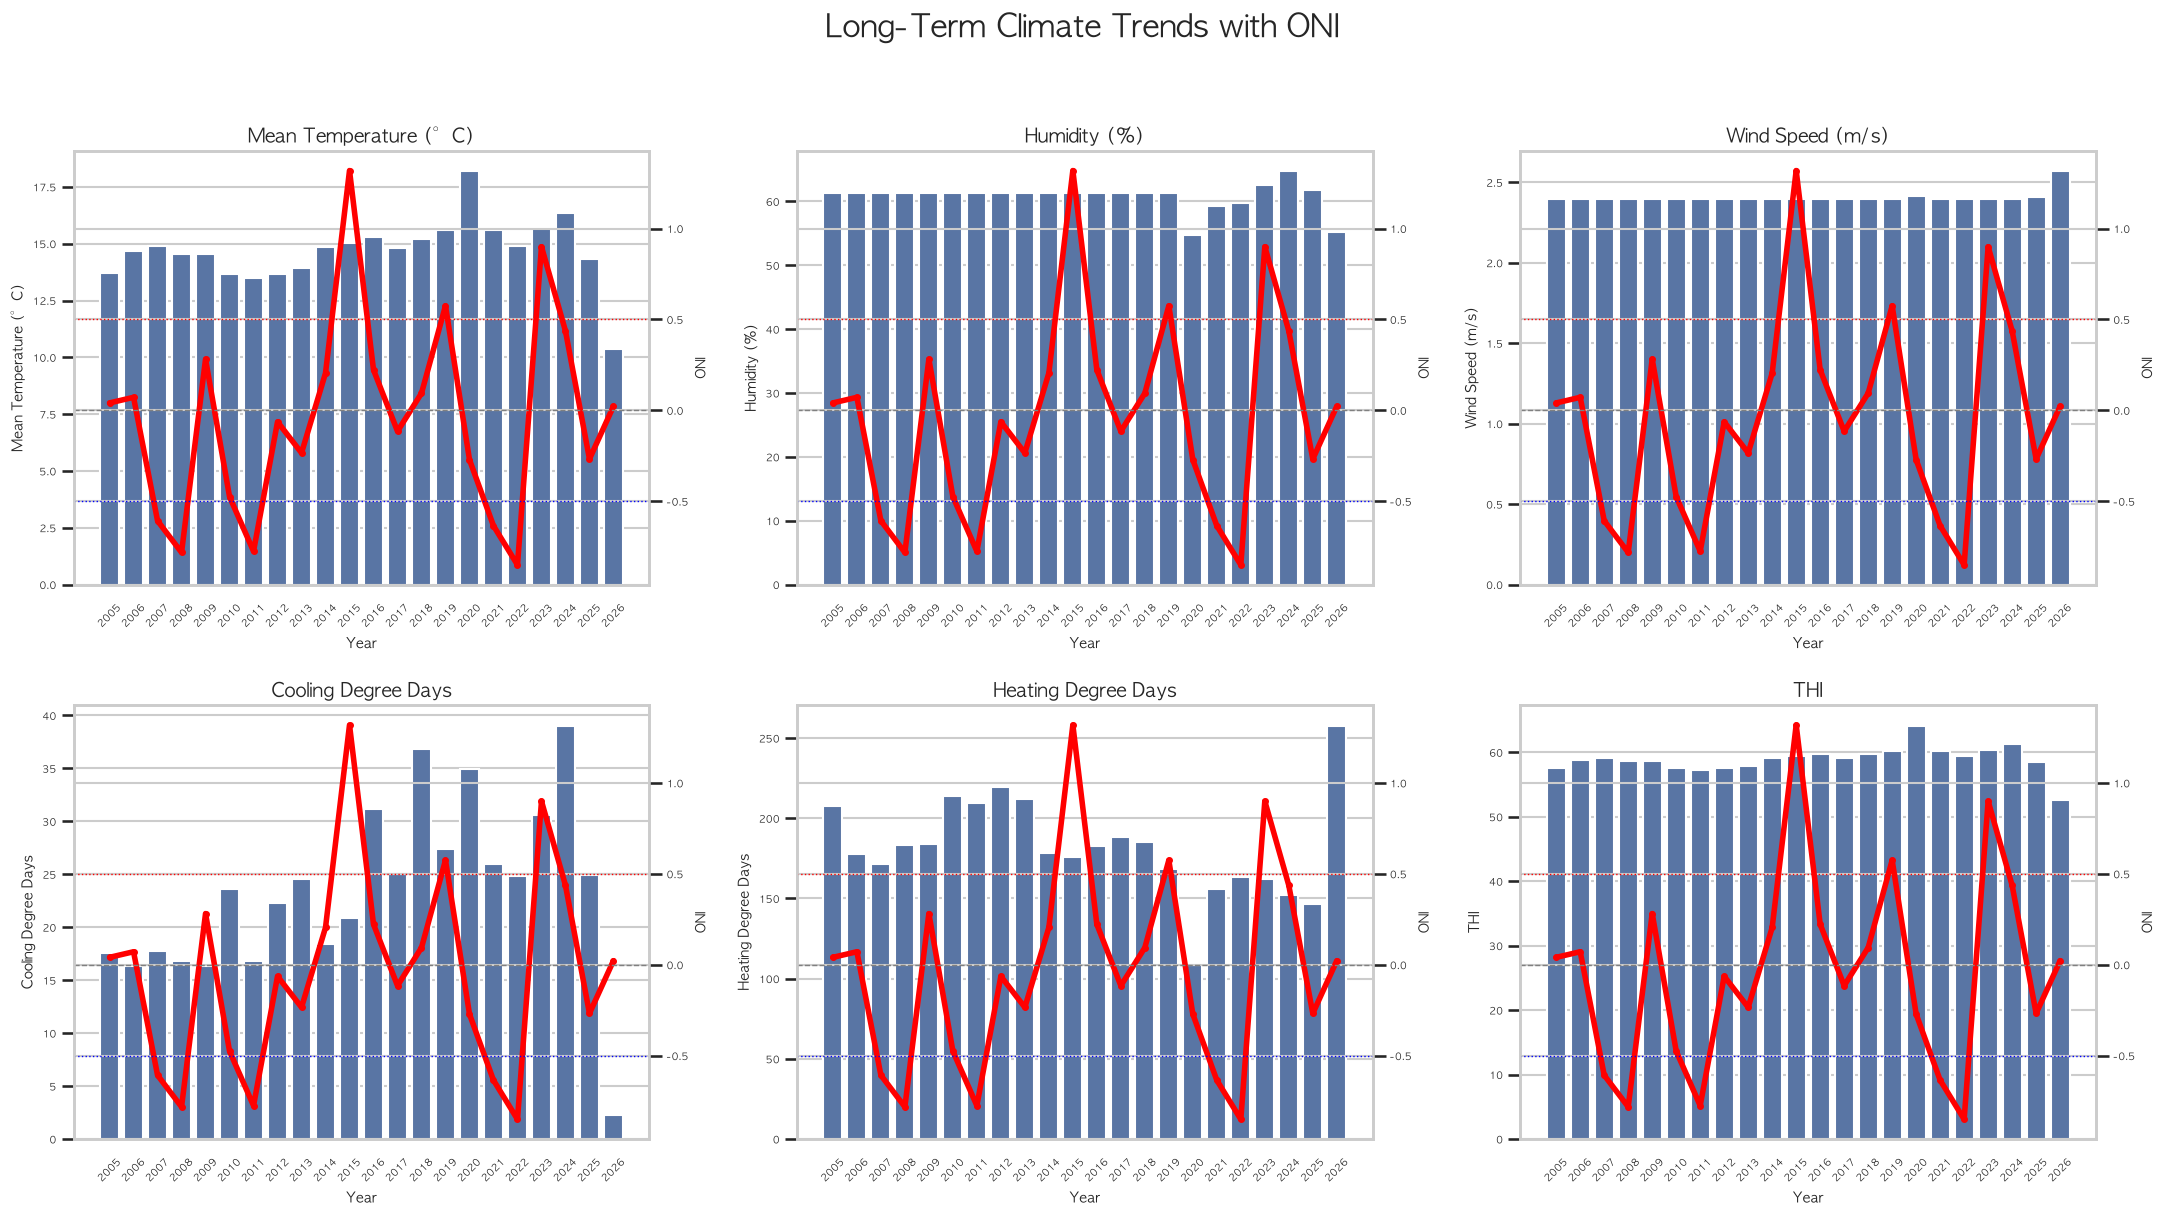

In [60]:
# =========================
# 연도별 기후 평균
# =========================
yearly = (
    temp
    .groupby("year")
    [
        [
            "ta_mean",
            "hm_mean",
            "ws_mean",
            "cdd",
            "hdd",
            "thi"
        ]
    ]
    .mean()
    .reset_index()
)

# =========================
# 기온 데이터 연도 기준 ONI 정리
# =========================
temp_years = yearly["year"].unique()

oni_yearly = (
    oni
    .groupby("year", as_index=False)["oni"]
    .mean()
)

oni_yearly = oni_yearly[
    oni_yearly["year"].isin(temp_years)
].copy()

# 혹시 연도 순서가 어긋나지 않도록 정렬
yearly = yearly.sort_values("year").reset_index(drop=True)
oni_yearly = oni_yearly.sort_values("year").reset_index(drop=True)

# =========================
# 시각화 변수 설정
# =========================
variables = [
    ("ta_mean", "Mean Temperature (°C)"),
    ("hm_mean", "Humidity (%)"),
    ("ws_mean", "Wind Speed (m/s)"),
    ("cdd", "Cooling Degree Days"),
    ("hdd", "Heating Degree Days"),
    ("thi", "THI")
]

# =========================
# 시각화
# =========================
fig, axes = plt.subplots(
    2, 3,
    figsize=(22, 12)
)

for ax, (col, title) in zip(
    axes.flat,
    variables
):

    # 기후 변수 막대그래프
    sns.barplot(
        data=yearly,
        x="year",
        y=col,
        ax=ax
    )

    ax.set_title(title, fontsize=14)
    ax.set_xlabel("Year", fontsize=10)
    ax.set_ylabel(title, fontsize=10)

    ax.tick_params(axis="x", labelsize=7)
    ax.tick_params(axis="y", labelsize=7)

    for label in ax.get_xticklabels():
        label.set_rotation(45)

    # =========================
    # ONI 추세선 추가
    # =========================
    ax2 = ax.twinx()

    ax2.plot(
        range(len(oni_yearly)),
        oni_yearly["oni"],
        color="red",
        marker="o",
        linewidth=4,
        markersize=4,
        label="ONI"
    )

    # ONI 기준선
    ax2.axhline(
        0,
        color="gray",
        linestyle="--",
        linewidth=1
    )

    ax2.axhline(
        0.5,
        color="red",
        linestyle=":",
        linewidth=1
    )

    ax2.axhline(
        -0.5,
        color="blue",
        linestyle=":",
        linewidth=1
    )

    ax2.set_ylabel("ONI", fontsize=9)
    ax2.tick_params(axis="y", labelsize=7)

plt.suptitle(
    "Long-Term Climate Trends with ONI",
    fontsize=22,
    y=1.02
)

plt.tight_layout()
plt.show()

### 냉방도일·난방도일·불쾌지수 장기 변화

냉방도일(CDD)은 냉방 수요,
난방도일(HDD)은 난방 수요를 의미한다.

장기 추세를 통해 기후변화가
에너지 수요에 미치는 영향을 분석한다.

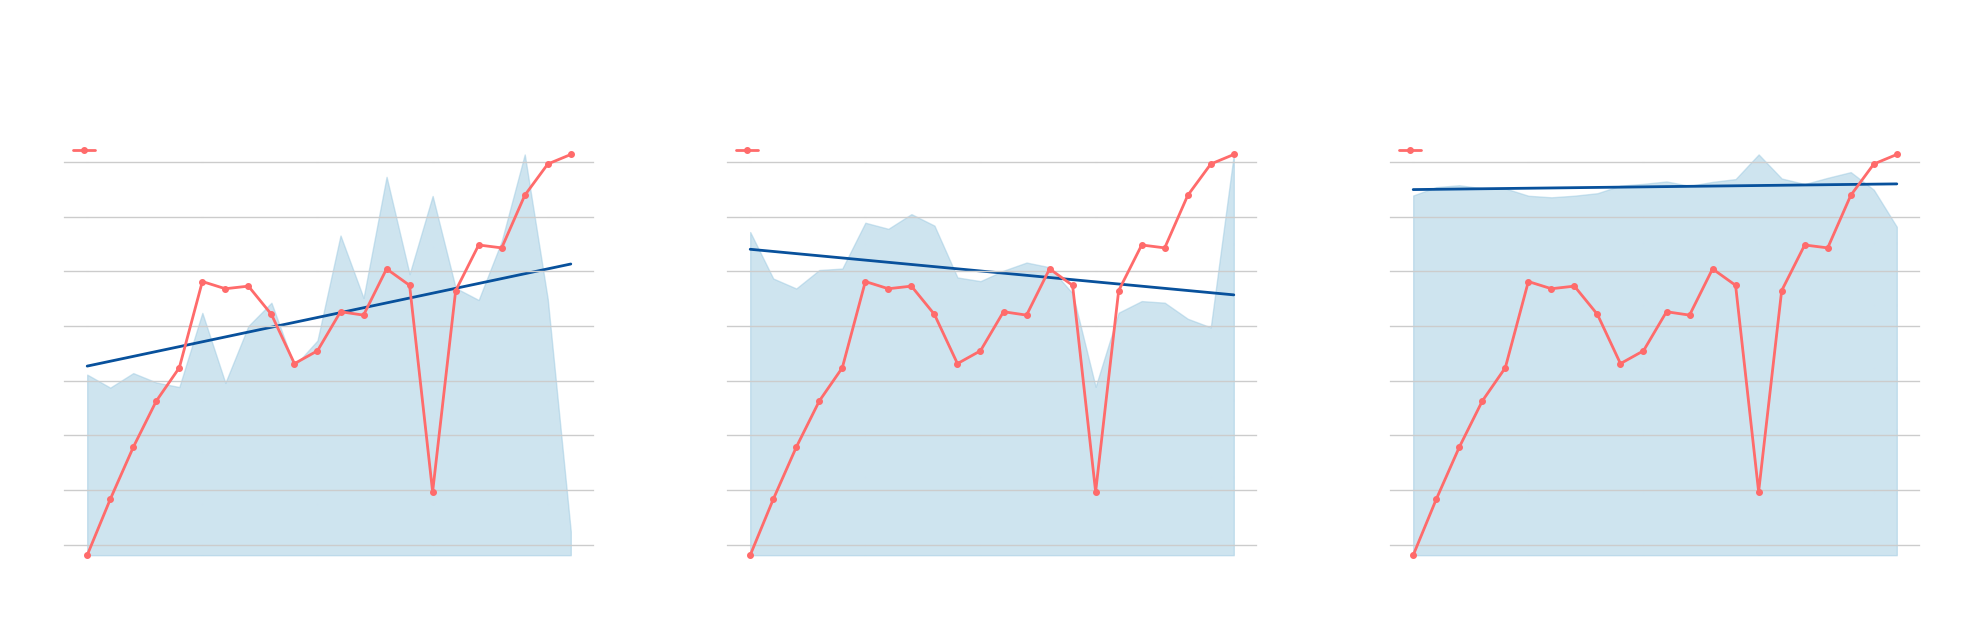

In [235]:
import seaborn as sns
import matplotlib.pyplot as plt

# =========================
# 흰색 테마
# =========================
plt.rcParams["font.family"] = "AppleGothic"
plt.rcParams["axes.unicode_minus"] = False

plt.rcParams.update({
    "text.color": "white",
    "axes.labelcolor": "white",
    "xtick.color": "white",
    "ytick.color": "white",
    "axes.edgecolor": "white"
})

# =========================
# 연도별 평균 전력사용량
# =========================
power_yearly = (
    kepco
    .groupby("year", as_index=False)["power_mwh"]
    .mean()
)

power_yearly["power_gwh"] = (
    power_yearly["power_mwh"] / 1000
)

# =========================
# 기후지표 연도별 평균
# =========================
yearly = (
    temp
    .groupby("year")
    [["cdd", "hdd", "thi"]]
    .mean()
    .reset_index()
)

# 연도 맞추기
power_yearly = power_yearly[
    power_yearly["year"].isin(yearly["year"])
].copy()

# =========================
# 시각화
# =========================
fig, axes = plt.subplots(
    1, 3,
    figsize=(20, 6),
    facecolor="none"
)

fig.patch.set_alpha(0)

for ax, col in zip(
    axes,
    ["cdd", "hdd", "thi"]
):

    # 배경 투명
    ax.set_facecolor("none")

    # 영역 그래프
    ax.fill_between(
        yearly["year"],
        yearly[col],
        alpha=0.5,
        color="#9ecae1"
    )

    # 추세선
    sns.regplot(
        data=yearly,
        x="year",
        y=col,
        scatter=False,
        ci=None,
        ax=ax,
        line_kws={
            "linewidth": 2,
            "color": "#08519c"
        }
    )

    # 축 스타일
    ax.set_title(
        col.upper(),
        fontsize=14,
        color="white",
        fontweight="bold"
    )

    ax.set_xlabel(
        "Year",
        color="white"
    )

    ax.set_ylabel(
        col.upper(),
        fontsize=12,
        color="white"
    )

    ax.tick_params(
        axis="both",
        labelsize=8,
        colors="white"
    )

    ax.grid(
        alpha=0.25,
        color="white"
    )

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.spines["left"].set_color("white")
    ax.spines["bottom"].set_color("white")

    # =========================
    # 전력사용량 추가
    # =========================
    ax2 = ax.twinx()

    ax2.plot(
        power_yearly["year"],
        power_yearly["power_gwh"],
        color="#FF6B6B",
        marker="o",
        linewidth=2,
        markersize=4,
        label="Power"
    )

    ax2.set_ylabel(
        "Power Consumption (GWh)",
        fontsize=12,
        color="white"
    )

    ax2.tick_params(
        axis="y",
        labelsize=8,
        colors="white"
    )

    ax2.spines["top"].set_visible(False)
    ax2.spines["right"].set_color("white")

    legend = ax2.legend(
        frameon=False,
        fontsize=8,
        loc="upper left"
    )

    for text in legend.get_texts():
        text.set_color("white")

# =========================
# 전체 제목
# =========================
fig.suptitle(
    "Long-Term Trends of Climate Indices and Power Consumption",
    fontsize=20,
    fontweight="bold",
    color="white",
    y=1.05
)

# =========================
# 저장
# =========================
plt.tight_layout()

plt.savefig(
    SAVE / "chart2.png",
    dpi=300,
    bbox_inches="tight",
    transparent=True
)

plt.show()

-> 냉방도일은 갈수록 증가, 난방도일은 갈수록 감소(2025년 좀 증가)

-> 불쾌지수는 변동 없음

-> ONI와 관련된 것은 그나마 CDD !

### 자치구별 평균 CDD/HDD map

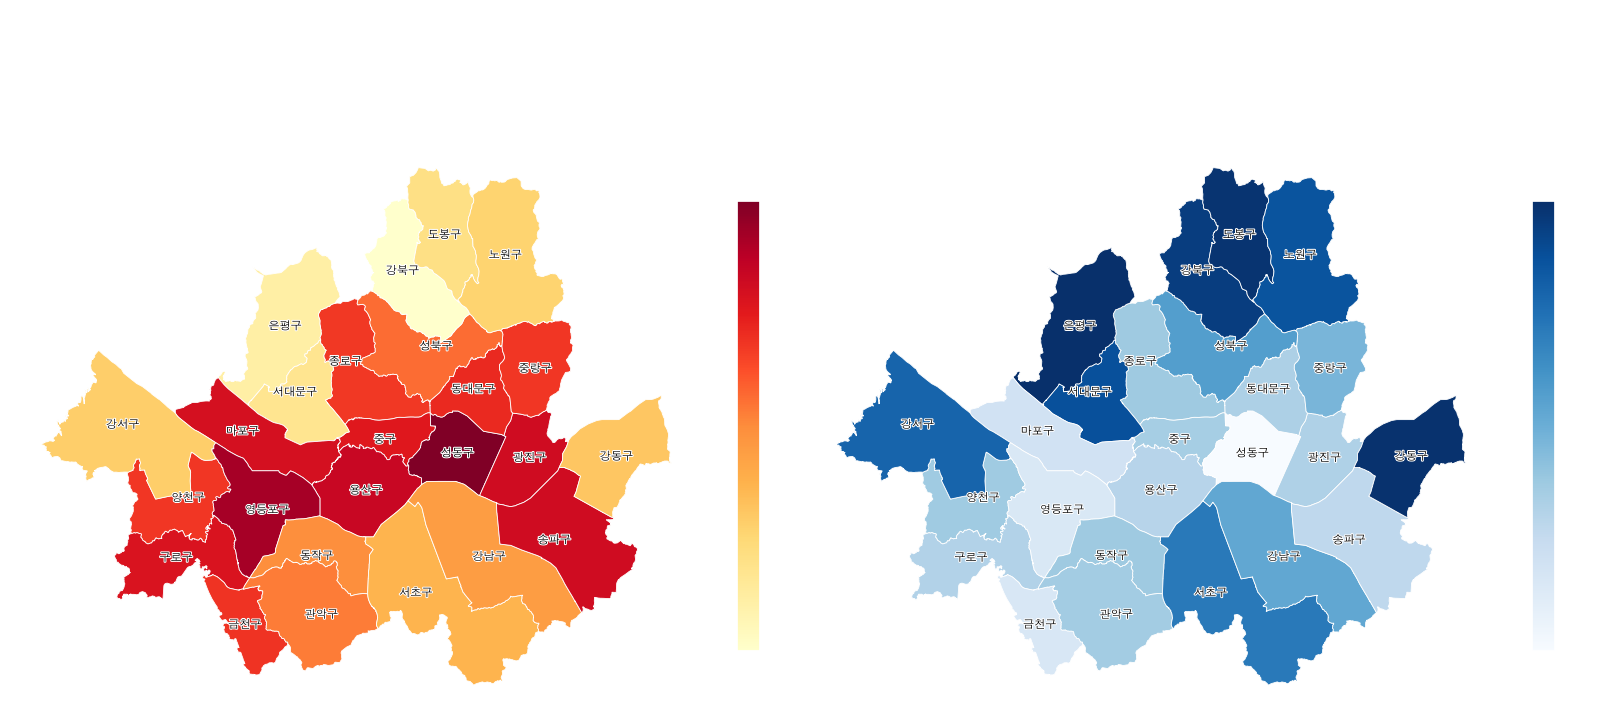

In [234]:
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe

# =====================
# 한글 폰트
# =====================
plt.rcParams["font.family"] = "AppleGothic"
plt.rcParams["axes.unicode_minus"] = False

# =====================
# 모든 글꼴 흰색
# =====================
plt.rcParams.update({
    "text.color": "white",
    "axes.labelcolor": "white",
    "xtick.color": "white",
    "ytick.color": "white",
    "axes.edgecolor": "white"
})

# =====================
# 좌표계 통일
# =====================
gu_geo = gu_geo.to_crs("EPSG:4326")

# =====================
# CDD / HDD 집계
# =====================
gu_climate = (
    temp
    .groupby("gu", as_index=False)
    [["cdd", "hdd"]]
    .mean()
)

geo = gu_geo.merge(
    gu_climate,
    left_on="SIGUNGU_NM",
    right_on="gu",
    how="left"
)

# =====================
# 라벨 위치 계산
# =====================
geo_label = geo.to_crs("EPSG:5179").copy()

geo_label["label_point"] = (
    geo_label.representative_point()
)

geo_label = (
    geo_label
    .set_geometry("label_point")
    .to_crs("EPSG:4326")
)

# =====================
# Figure
# =====================
fig, axes = plt.subplots(
    1, 2,
    figsize=(16, 8),
    constrained_layout=True,
    facecolor="none"
)

fig.patch.set_alpha(0)

# =====================
# CDD
# =====================
geo.plot(
    column="cdd",
    cmap="YlOrRd",
    legend=True,
    edgecolor="white",
    linewidth=0.6,
    ax=axes[0],
    legend_kwds={
        "shrink": 0.6
    }
)

axes[0].set_facecolor("none")

# 컬러바 흰색
cbar1 = fig.axes[-2]

cbar1.tick_params(
    labelsize=8,
    colors="white"
)

for spine in cbar1.spines.values():
    spine.set_color("white")

axes[0].set_title(
    "Average Cooling Degree Days (CDD)",
    fontsize=13,
    color="white",
    fontweight="bold"
)

for _, row in geo_label.iterrows():

    axes[0].text(
        row["label_point"].x,
        row["label_point"].y,
        row["SIGUNGU_NM"],
        fontsize=8,
        color="black",
        fontweight="bold",
        ha="center",
        va="center",
        path_effects=[
            pe.withStroke(
                linewidth=1.5,
                foreground="white"
            )
        ]
    )

axes[0].axis("off")

# =====================
# HDD
# =====================
geo.plot(
    column="hdd",
    cmap="Blues",
    legend=True,
    edgecolor="white",
    linewidth=0.6,
    ax=axes[1],
    legend_kwds={
        "shrink": 0.6
    }
)

axes[1].set_facecolor("none")

# 컬러바 흰색
cbar2 = fig.axes[-1]

cbar2.tick_params(
    labelsize=8,
    colors="white"
)

for spine in cbar2.spines.values():
    spine.set_color("white")

axes[1].set_title(
    "Average Heating Degree Days (HDD)",
    fontsize=13,
    color="white",
    fontweight="bold"
)

for _, row in geo_label.iterrows():

    axes[1].text(
        row["label_point"].x,
        row["label_point"].y,
        row["SIGUNGU_NM"],
        fontsize=8,
        color="black",
        fontweight="bold",
        ha="center",
        va="center",
        path_effects=[
            pe.withStroke(
                linewidth=1.5,
                foreground="white"
            )
        ]
    )

axes[1].axis("off")

# =====================
# 전체 제목
# =====================
fig.suptitle(
    "자치구별 CDD / HDD",
    fontsize=20,
    fontweight="bold",
    color="white"
)

# =====================
# 저장
# =====================
plt.savefig(
    SAVE / "chart3.png",
    dpi=300,
    bbox_inches="tight",
    transparent=True
)

plt.show()

# KEPCO


| 컬럼                   | 설명               |
| -------------------- | ---------------- |
| year                 | 연도               |
| month                | 월                |
| sigungu              | 시군구              |
| usage_type           | 전력용도             |
| building_type        | 건축용도             |
| power_mwh            | 전력사용량(MWh)       |
| usage_ratio          | 시군구 내 전력사용 비율(%) |
| capacity_mw          | 공급능력(MW)         |
| peak_mw              | 최대전력(MW)         |
| reserve_mw           | 공급예비력(MW)        |
| reserve_rate         | 공급예비율(%)         |
| reduction_need_score | 수요감축필요도 점수       |

### Power Consumption Characteristics

본 분석은 서울시 전력 사용량(power_mwh)의 공간적·시간적 특성을 파악하기 위해 수행하였다.

#### Figure 구성

1. 구별 평균 전력사용량
   - 전력 소비가 집중되는 지역 확인

2. 연도별 평균 전력사용량 + ONI
   - ENSO(엘니뇨/라니냐)와 장기 전력 수요 변화 비교

3. 월별 평균 전력사용량 + ONI
   - 계절성과 ENSO 영향 탐색

4. 전력용도별 평균 전력사용량
   - 어떤 용도가 가장 많은 전력을 소비하는지 확인

### Electricity Supply Reserve Rate

공급예비율은 전력 공급 안정성을 나타내는 대표 지표이다.

- 높은 공급예비율 → 전력 공급 여유
- 낮은 공급예비율 → 정전 및 수급 위험 증가

월별 및 연도별 변화를 분석하여 전력 시스템의 안정성 변화를 확인한다.

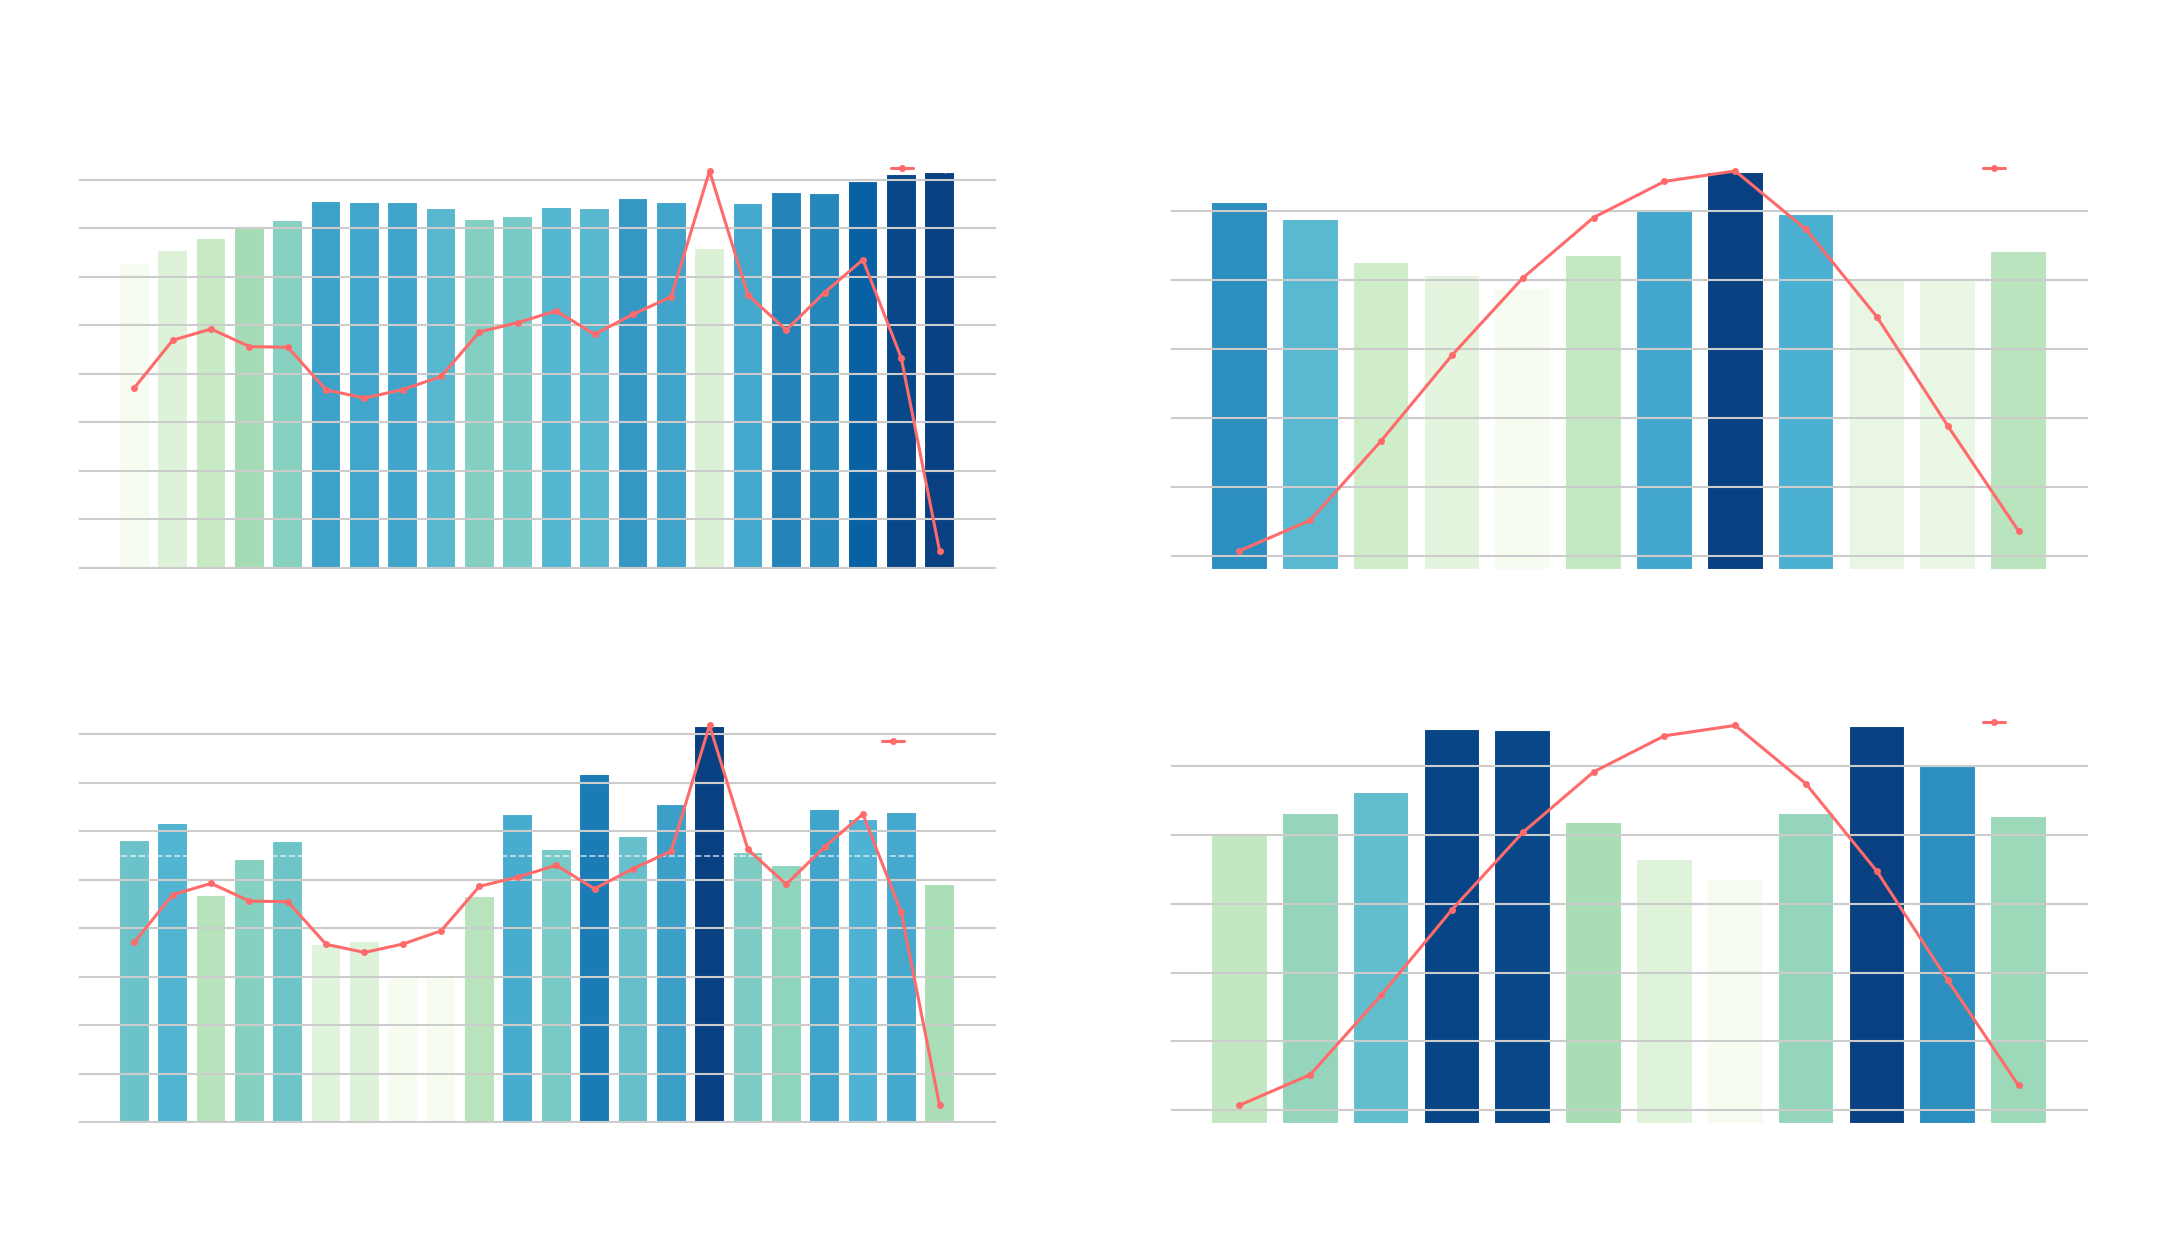

In [237]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.colors import Normalize

plt.rc("font", family="AppleGothic")
plt.rcParams["axes.unicode_minus"] = False

# =====================
# 흰색 글꼴 설정
# =====================
plt.rcParams.update({
    "text.color": "white",
    "axes.labelcolor": "white",
    "xtick.color": "white",
    "ytick.color": "white",
    "axes.edgecolor": "white"
})

# =====================
# 1. 데이터 집계
# =====================
year_power = (
    kepco.groupby("year", as_index=False)["power_mwh"]
    .mean()
    .sort_values("year")
)

month_power = (
    kepco.groupby("month", as_index=False)["power_mwh"]
    .mean()
    .sort_values("month")
)

reserve_year = (
    kepco[["year", "reserve_rate"]]
    .drop_duplicates()
    .groupby("year", as_index=False)["reserve_rate"]
    .mean()
    .sort_values("year")
)

reserve_month = (
    kepco[["year", "month", "reserve_rate"]]
    .drop_duplicates()
    .groupby("month", as_index=False)["reserve_rate"]
    .mean()
    .sort_values("month")
)

year_temp = (
    temp.groupby("year", as_index=False)["ta_mean"]
    .mean()
    .sort_values("year")
)

month_temp = (
    temp.groupby("month", as_index=False)["ta_mean"]
    .mean()
    .sort_values("month")
)

year_power["power_gwh"] = year_power["power_mwh"] / 1000
month_power["power_gwh"] = month_power["power_mwh"] / 1000

# =====================
# 2. 디자인 설정
# =====================
line_color = "#FF6B6B"
grid_color = "white"

fig, axes = plt.subplots(
    2, 2,
    figsize=(22, 12),
    facecolor="none"
)

fig.patch.set_alpha(0)

# =====================
# 공통 스타일 함수
# =====================
def style_axis(ax):
    ax.set_facecolor("none")
    ax.grid(
        axis="y",
        color=grid_color,
        linestyle="-",
        linewidth=0.8,
        alpha=0.25
    )
    ax.grid(axis="x", visible=False)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color("white")
    ax.spines["bottom"].set_color("white")

    ax.tick_params(
        axis="both",
        labelsize=8,
        colors="white"
    )

    ax.title.set_color("white")
    ax.xaxis.label.set_color("white")
    ax.yaxis.label.set_color("white")


def style_twin_axis(ax):
    ax.set_facecolor("none")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_color("white")

    ax.tick_params(
        axis="y",
        labelsize=8,
        colors="white"
    )

    ax.yaxis.label.set_color("white")


def set_legend_white(legend):
    if legend is not None:
        for text in legend.get_texts():
            text.set_color("white")


def get_colors(values):
    return cm.GnBu(
        Normalize(
            values.min(),
            values.max()
        )(values)
    )


for ax in axes.flat:
    style_axis(ax)

# =====================
# 1. 연도별 전력사용량 + 기온
# =====================
ax = axes[0, 0]

year_power_plot = year_power.merge(
    year_temp,
    on="year",
    how="left"
)

x = np.arange(len(year_power_plot))

ax.bar(
    x,
    year_power_plot["power_gwh"],
    color=get_colors(year_power_plot["power_gwh"]),
    edgecolor="white"
)

ax.set_xticks(x)
ax.set_xticklabels(year_power_plot["year"], rotation=45)
ax.set_title("1. Yearly Power Consumption and Temperature", fontweight="bold", fontsize = 15)
ax.set_xlabel("Year")
ax.set_ylabel("Power Consumption (GWh)")

ax2 = ax.twinx()
style_twin_axis(ax2)

ax2.plot(
    x,
    year_power_plot["ta_mean"],
    color=line_color,
    marker="o",
    linewidth=2.2,
    markersize=4,
    label="Temperature"
)

ax2.set_ylabel("Average Temperature (℃)", color="white")

legend = ax2.legend(
    frameon=False,
    loc="upper right",
    fontsize=8
)
set_legend_white(legend)

# =====================
# 2. 월별 전력사용량 + 기온
# =====================
ax = axes[0, 1]

month_power_plot = month_power.merge(
    month_temp,
    on="month",
    how="left"
)

x = np.arange(len(month_power_plot))

ax.bar(
    x,
    month_power_plot["power_gwh"],
    color=get_colors(month_power_plot["power_gwh"]),
    edgecolor="white"
)

ax.set_xticks(x)
ax.set_xticklabels(month_power_plot["month"])
ax.set_title("2. Monthly Power Consumption and Temperature", fontweight="bold", fontsize = 15)
ax.set_xlabel("Month")
ax.set_ylabel("Power Consumption (GWh)")

ax3 = ax.twinx()
style_twin_axis(ax3)

ax3.plot(
    x,
    month_power_plot["ta_mean"],
    color=line_color,
    marker="o",
    linewidth=2.2,
    markersize=4,
    label="Temperature"
)

ax3.set_ylabel("Average Temperature (℃)", color="white")

legend = ax3.legend(
    frameon=False,
    loc="upper right",
    fontsize=8
)
set_legend_white(legend)

# =====================
# 3. 연도별 공급예비율 + 기온
# =====================
ax = axes[1, 0]

reserve_year_plot = reserve_year.merge(
    year_temp,
    on="year",
    how="left"
)

x = np.arange(len(reserve_year_plot))

ax.bar(
    x,
    reserve_year_plot["reserve_rate"],
    color=get_colors(reserve_year_plot["reserve_rate"]),
    edgecolor="white"
)

ax.set_xticks(x)
ax.set_xticklabels(reserve_year_plot["year"], rotation=45)
ax.set_title("3. Yearly Reserve Rate and Temperature", fontweight="bold", fontsize = 15)
ax.set_xlabel("Year")
ax.set_ylabel("Reserve Rate (%)")

yearly_mean = reserve_year_plot["reserve_rate"].mean()

ax.axhline(
    yearly_mean,
    color="white",
    linestyle="--",
    linewidth=1.2,
    alpha=0.7,
    label=f"Mean: {yearly_mean:.1f}%"
)

ax4 = ax.twinx()
style_twin_axis(ax4)

ax4.plot(
    x,
    reserve_year_plot["ta_mean"],
    color=line_color,
    marker="o",
    linewidth=2.2,
    markersize=4,
    label="Temperature"
)

ax4.set_ylabel("Average Temperature (℃)", color="white")

lines_1, labels_1 = ax.get_legend_handles_labels()
lines_2, labels_2 = ax4.get_legend_handles_labels()

legend = ax.legend(
    lines_1 + lines_2,
    labels_1 + labels_2,
    frameon=False,
    loc="upper right",
    fontsize=8
)
set_legend_white(legend)

# =====================
# 4. 월별 공급예비율 + 기온
# =====================
ax = axes[1, 1]

reserve_month_plot = reserve_month.merge(
    month_temp,
    on="month",
    how="left"
)

x = np.arange(len(reserve_month_plot))

ax.bar(
    x,
    reserve_month_plot["reserve_rate"],
    color=get_colors(reserve_month_plot["reserve_rate"]),
    edgecolor="white"
)

ax.set_xticks(x)
ax.set_xticklabels(reserve_month_plot["month"])
ax.set_title("4. Monthly Reserve Rate and Temperature", fontweight="bold", fontsize = 15)
ax.set_xlabel("Month")
ax.set_ylabel("Reserve Rate (%)")

ax5 = ax.twinx()
style_twin_axis(ax5)

ax5.plot(
    x,
    reserve_month_plot["ta_mean"],
    color=line_color,
    marker="o",
    linewidth=2.2,
    markersize=4,
    label="Temperature"
)

ax5.set_ylabel("Average Temperature (℃)", color="white")

legend = ax5.legend(
    frameon=False,
    loc="upper right",
    fontsize=8
)
set_legend_white(legend)

# =====================
# 전체 제목 / 설명
# =====================
fig.suptitle(
    "Power Consumption, Reserve Rate and Temperature Analysis",
    fontsize=22,
    fontweight="bold",
    y=1.02,
    color="white"
)

fig.text(
    0.5,
    0.01,
    "Note: Power consumption is converted from MWh to GWh. Temperature values are shown on the secondary y-axis.",
    ha="center",
    fontsize=9,
    color="white"
)

plt.tight_layout()

plt.savefig(
    SAVE / "chart4.png",
    dpi=300,
    bbox_inches="tight",
    transparent=True
)

plt.show()

### 자치구별 전력 사용량

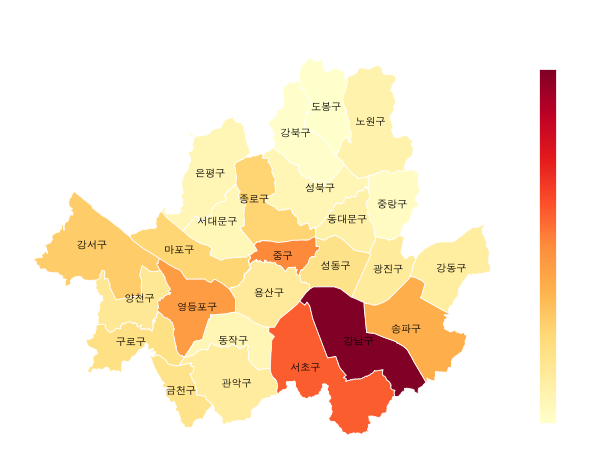

In [232]:
import geopandas as gpd
import matplotlib.pyplot as plt

# =====================
# 흰색 텍스트 테마
# =====================
plt.rcParams["font.family"] = "AppleGothic"
plt.rcParams["axes.unicode_minus"] = False

plt.rcParams.update({
    "text.color": "white",
    "axes.labelcolor": "white",
    "xtick.color": "white",
    "ytick.color": "white",
    "axes.edgecolor": "white"
})

# =====================
# 좌표계 통일
# =====================
gu_geo = gu_geo.to_crs("EPSG:4326")

# =====================
# 시군구별 평균 전력사용량
# =====================
gu_power = (
    kepco
    .groupby("sigungu", as_index=False)["power_mwh"]
    .mean()
)

# =====================
# shp 결합
# =====================
geo = gu_geo.merge(
    gu_power,
    left_on="SIGUNGU_NM",
    right_on="sigungu",
    how="left"
)

# =====================
# 라벨 위치 계산
# =====================
geo_label = geo.to_crs("EPSG:5179").copy()

geo_label["label_point"] = (
    geo_label.representative_point()
)

geo_label = (
    geo_label
    .set_geometry("label_point")
    .to_crs("EPSG:4326")
)

# =====================
# 시각화
# =====================
fig, ax = plt.subplots(
    1, 1,
    figsize=(6, 6),
    constrained_layout=True
)

# 배경 투명
fig.patch.set_alpha(0)
ax.set_facecolor("none")

geo.plot(
    column="power_mwh",
    cmap="YlOrRd",
    legend=True,
    edgecolor="white",
    linewidth=0.6,
    ax=ax,
    missing_kwds={
        "color": "#444444",
        "edgecolor": "white",
        "label": "No data"
    },
    legend_kwds={
        "shrink": 0.6
    }
)

# =====================
# 컬러바 설정
# =====================
cbar_ax = fig.axes[-1]

cbar_ax.tick_params(
    labelsize=6,
    colors="white"
)

for spine in cbar_ax.spines.values():
    spine.set_color("white")

# =====================
# 제목
# =====================
ax.set_title(
    "Average Power Consumption by District",
    fontsize=13,
    color="white",
    fontweight="bold",
    pad=10
)

# =====================
# 시군구명
# =====================
for _, row in geo_label.iterrows():

    ax.text(
        row["label_point"].x,
        row["label_point"].y,
        row["SIGUNGU_NM"],
        fontsize=7,
        color="black",
        fontweight="bold",
        ha="center",
        va="center"
    )

ax.axis("off")

# =====================
# 저장
# =====================
plt.savefig(
    SAVE / "chart5.png",
    dpi=300,
    bbox_inches="tight",
    transparent=True
)

plt.show()

# ONI

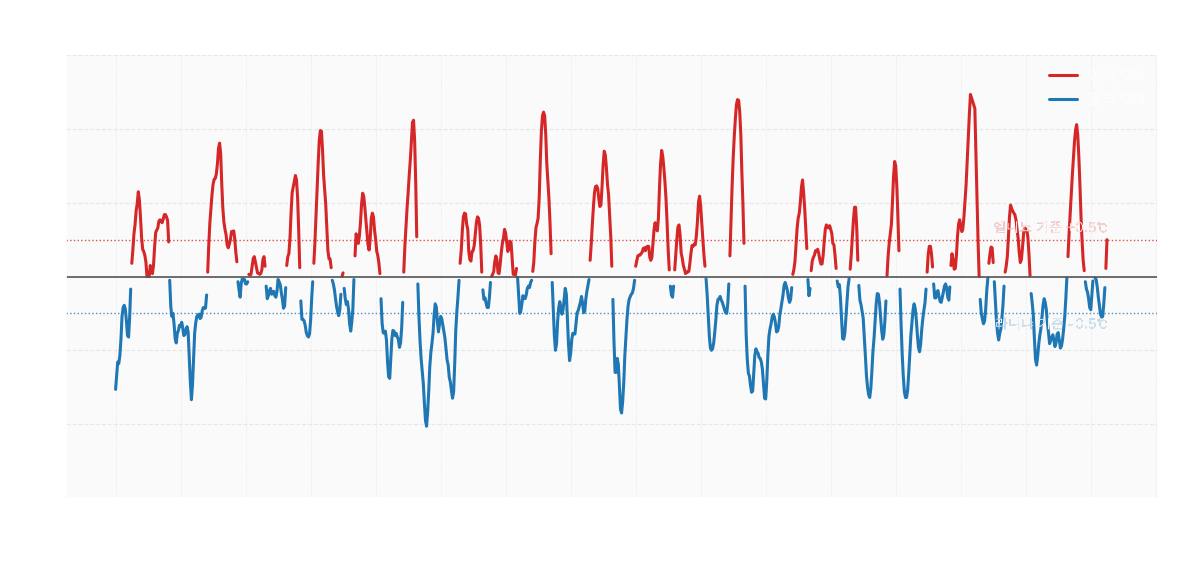

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

plt.rcParams["font.family"] = "AppleGothic"
plt.rcParams["axes.unicode_minus"] = False

# =====================
# 날짜 컬럼 생성
# =====================
oni_plot = oni.copy()

oni_plot["date"] = pd.to_datetime(
    oni_plot["year"].astype(str) + "-" +
    oni_plot["month"].astype(str).str.zfill(2) + "-01"
)

oni_plot = oni_plot.sort_values("date").reset_index(drop=True)

oni_plot["oni_pos"] = oni_plot["oni"].where(oni_plot["oni"] >= 0)
oni_plot["oni_neg"] = oni_plot["oni"].where(oni_plot["oni"] < 0)

# =====================
# 시각화
# =====================
fig, ax = plt.subplots(figsize=(12, 6), facecolor="white")
ax.set_facecolor("#FAFAFA")

# 양수 / 음수 선
ax.plot(
    oni_plot["date"],
    oni_plot["oni_pos"],
    color="#D62728",
    linewidth=2.2,
    label="양의 ONI"
)

ax.plot(
    oni_plot["date"],
    oni_plot["oni_neg"],
    color="#1F77B4",
    linewidth=2.2,
    label="음의 ONI"
)

# 0 기준선
ax.axhline(
    0,
    color="#555555",
    linewidth=1.2,
    linestyle="-"
)

# 엘니뇨 / 라니냐 기준선
ax.axhline(
    0.5,
    color="#D62728",
    linewidth=1,
    linestyle=":",
    alpha=0.8
)

ax.axhline(
    -0.5,
    color="#1F77B4",
    linewidth=1,
    linestyle=":",
    alpha=0.8
)

# 기준선 라벨
ax.text(
    oni_plot["date"].iloc[-1],
    0.55,
    "엘니뇨 기준 +0.5℃",
    fontsize=9,
    color="#D62728",
    va="bottom",
    ha="right"
)

ax.text(
    oni_plot["date"].iloc[-1],
    -0.55,
    "라니냐 기준 -0.5℃",
    fontsize=9,
    color="#1F77B4",
    va="top",
    ha="right"
)

# 그리드
ax.grid(
    axis="y",
    linestyle="--",
    linewidth=0.8,
    alpha=0.4
)

ax.grid(
    axis="x",
    linestyle="--",
    linewidth=0.6,
    alpha=0.25
)

# 축 디자인
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color("#BBBBBB")
ax.spines["bottom"].set_color("#BBBBBB")

# x축 연도 간격
ax.xaxis.set_major_locator(mdates.YearLocator(5))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

ax.tick_params(axis="x", rotation=45, labelsize=9)
ax.tick_params(axis="y", labelsize=10)

# 제목 및 축
ax.set_title(
    "엘니뇨·라니냐 지수(ONI)의 장기 변동 추이",
    fontsize=15,
    fontweight="bold",
    color = 'white',
    pad=20
)

ax.set_xlabel("연도", fontsize=12)
ax.set_ylabel("ONI 해수면 온도 편차 (℃)", fontsize=12)

ax.set_ylim(-3, 3)

# 범례
ax.legend(
    frameon=False,
    fontsize=10,
    loc="upper right"
)

# =====================
# 제목 및 축
# =====================
ax.set_title(
    "엘니뇨·라니냐 지수(ONI)의 장기 변동 추이",
    fontsize=15,
    fontweight="bold",
    color="white",
    pad=20
)

ax.set_xlabel(
    "연도",
    fontsize=12,
    color="white"
)

ax.set_ylabel(
    "ONI 해수면 온도 편차 (℃)",
    fontsize=12,
    color="white"
)

# =====================
# 눈금 글자 색
# =====================
ax.tick_params(
    axis="x",
    rotation=45,
    labelsize=9,
    colors="white"
)

ax.tick_params(
    axis="y",
    labelsize=10,
    colors="white"
)

# =====================
# 축 선 색
# =====================
ax.spines["left"].set_color("white")
ax.spines["bottom"].set_color("white")

# =====================
# 범례 글자 색
# =====================
legend = ax.legend(
    frameon=False,
    fontsize=10,
    loc="upper right"
)

cbar = ax.collections[0].colorbar
cbar.ax.tick_params(
    labelsize=6,
    colors="white"
)

cbar.outline.set_edgecolor("white")

# =====================
# 기준선 라벨 색
# =====================
ax.text(
    oni_plot["date"].iloc[-1],
    0.55,
    "엘니뇨 기준 +0.5℃",
    fontsize=9,
    color="white",
    va="bottom",
    ha="right"
)

ax.text(
    oni_plot["date"].iloc[-1],
    -0.55,
    "라니냐 기준 -0.5℃",
    fontsize=9,
    color="white",
    va="top",
    ha="right"
)

plt.tight_layout()
plt.savefig(SAVE/"chart6.png",
            dpi=300,
            bbox_inches="tight",
            transparent=True)

plt.show()



# 전력 + 기후 + ONI 상관관계

1. 연도별/월별 전력 + 기온 상관관계(regplot)
2. 연도별/월별 전력 + ONI 상관관계(regplot)

## 산점도 분석

#### 분석 데이터 구축

In [245]:
# =====================
# 1. 월별·구별·용도별 전력 사용량
# =====================
power_month = (
    kepco
    .groupby(
        ["year", "month", "sigungu", "usage_type"],
        as_index=False
    )["usage_ratio"]
    .sum()
)

# =====================
# 2. 월별 기후 평균
# =====================
temp_month = (
    temp
    .groupby(["year", "month"], as_index=False)
    [["ta_mean", "cdd", "hdd", "thi"]]
    .mean()
)

# =====================
# 3. 월별 공급예비율
# =====================
reserve = (
    kepco[["year", "month", "reserve_rate"]]
    .drop_duplicates()
)

# =====================
# 4. 분석용 데이터 생성
# =====================
df = (
    power_month
    .merge(temp_month, on=["year", "month"], how="left")
    .merge(oni, on=["year", "month"], how="left")
    .merge(reserve, on=["year", "month"], how="left")
)


feature = [
    "usage_ratio",
    "ta_mean",
    "cdd",
    "hdd",
    "thi",
    "oni",
    "reserve_rate"
]

corr = df[feature].corr()

#### 산점도 상관관계 분석

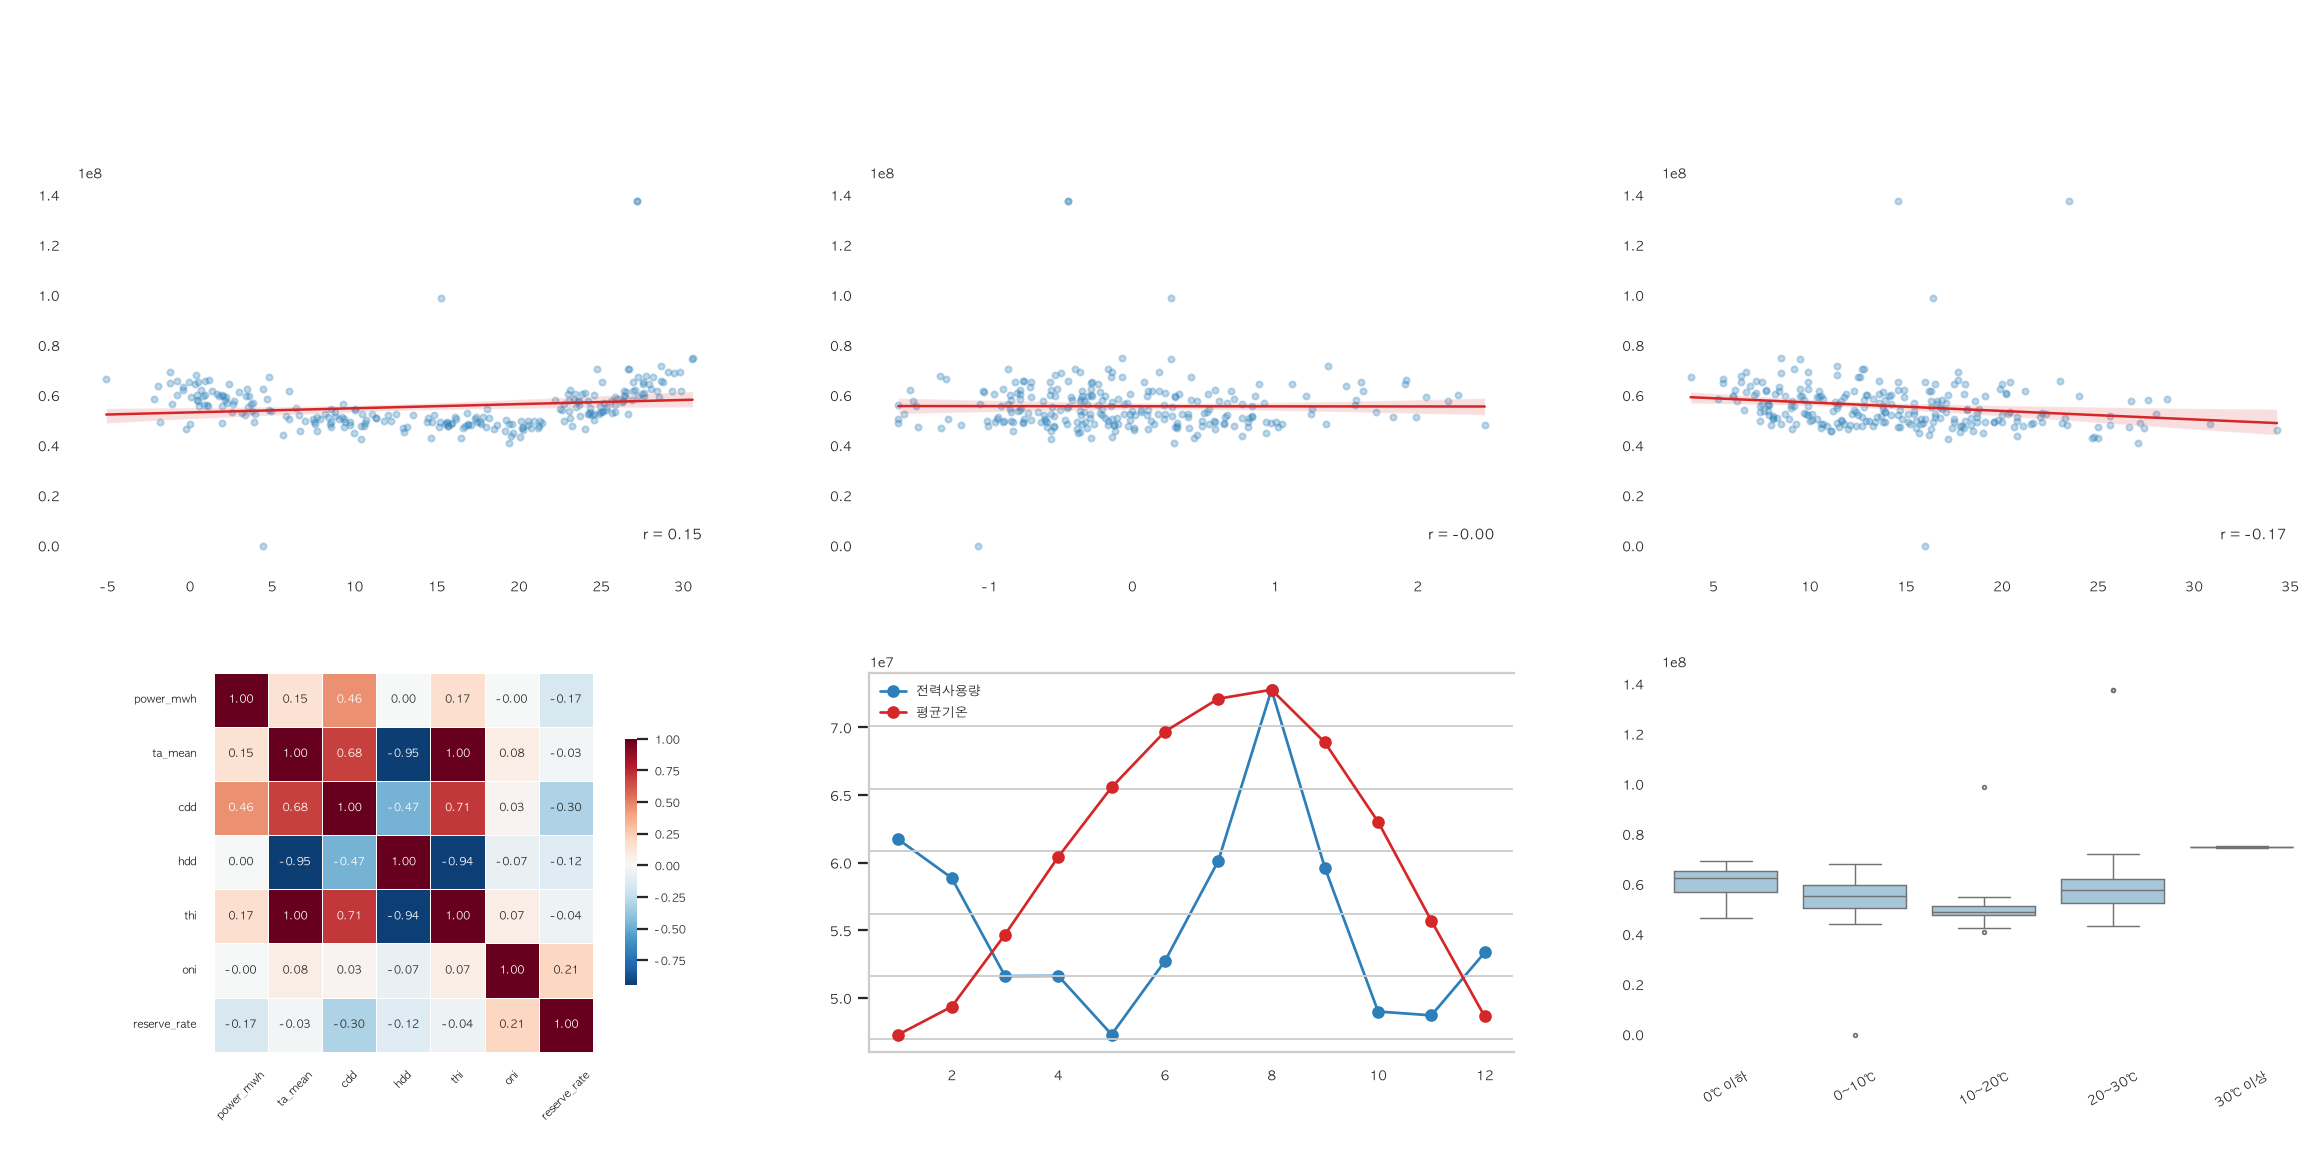

In [230]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "AppleGothic"
plt.rcParams["axes.unicode_minus"] = False

# =====================
# 흰색 테마
# =====================
plt.rcParams.update({
    "text.color": "white",
    "axes.labelcolor": "white",
    "xtick.color": "white",
    "ytick.color": "white",
    "axes.edgecolor": "white"
})

plt.rcParams["font.family"] = "AppleGothic"
plt.rcParams["axes.unicode_minus"] = False

sns.set_theme(
    style="whitegrid",
    font="AppleGothic",
    rc={
        "axes.titlesize": 9,
        "axes.labelsize": 8,
        "xtick.labelsize": 7,
        "ytick.labelsize": 7,
        "legend.fontsize": 7
    }
)

# =====================
# 기온 구간 생성
# =====================
df_plot = df.copy()

df_plot["temp_group"] = pd.cut(
    df_plot["ta_mean"],
    bins=[-20, 0, 10, 20, 30, 40],
    labels=["0℃ 이하", "0~10℃", "10~20℃", "20~30℃", "30℃ 이상"]
)

monthly_pattern = (
    df_plot
    .groupby("month", as_index=False)
    [["power_mwh", "ta_mean", "reserve_rate"]]
    .mean()
)

# =====================
# Figure
# =====================
fig, axes = plt.subplots(
    2, 3,
    figsize=(18, 9),
    dpi=130
)

fig.patch.set_alpha(0)

plot_style = {
    "scatter_kws": {
        "alpha": 0.3,
        "s": 12,
        "color": "#2C7FB8"
    },
    "line_kws": {
        "color": "#D62728",
        "linewidth": 1.4
    }
}

# =====================
# 1. 전력 vs 평균기온
# =====================
ax = axes[0, 0]

sns.regplot(
    data=df_plot,
    x="ta_mean",
    y="power_mwh",
    ax=ax,
    **plot_style
)

r = df_plot["ta_mean"].corr(df_plot["power_mwh"])

ax.set_title("전력사용량 vs 평균기온", pad=8)
ax.set_xlabel("평균기온 (℃)")
ax.set_ylabel("전력사용량 (MWh)")
ax.text(0.97, 0.05, f"r = {r:.2f}", transform=ax.transAxes,
        ha="right", va="bottom", fontsize=8, fontweight="bold")

# =====================
# 2. 전력 vs ONI
# =====================
ax = axes[0, 1]

sns.regplot(
    data=df_plot,
    x="oni",
    y="power_mwh",
    ax=ax,
    **plot_style
)

r = df_plot["oni"].corr(df_plot["power_mwh"])

ax.set_title("전력사용량 vs ONI", pad=8)
ax.set_xlabel("ONI")
ax.set_ylabel("전력사용량 (MWh)")
ax.text(0.97, 0.05, f"r = {r:.2f}", transform=ax.transAxes,
        ha="right", va="bottom", fontsize=8, fontweight="bold")

# =====================
# 3. 전력 vs 공급예비율
# =====================
ax = axes[0, 2]

sns.regplot(
    data=df_plot,
    x="reserve_rate",
    y="power_mwh",
    ax=ax,
    **plot_style
)

r = df_plot["reserve_rate"].corr(df_plot["power_mwh"])

ax.set_title("전력사용량 vs 공급예비율", pad=8)
ax.set_xlabel("공급예비율 (%)")
ax.set_ylabel("전력사용량 (MWh)")
ax.text(0.97, 0.05, f"r = {r:.2f}", transform=ax.transAxes,
        ha="right", va="bottom", fontsize=8, fontweight="bold")

# =====================
# 4. 상관계수 Heatmap
# =====================
ax = axes[1, 0]

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    square=True,
    linewidths=0.5,
    linecolor="white",
    annot_kws={"fontsize": 6},
    cbar_kws={"shrink": 0.65},
    ax=ax
)

ax.set_title("상관계수 Heatmap", pad=8)
ax.tick_params(axis="x", labelrotation=45, labelsize=6)
ax.tick_params(axis="y", labelrotation=0, labelsize=6)

cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=6)

# =====================
# 5. 월별 전력·기온 패턴
# =====================
ax = axes[1, 1]

ax.plot(
    monthly_pattern["month"],
    monthly_pattern["power_mwh"],
    marker="o",
    linewidth=1.5,
    color="#2C7FB8",
    label="전력사용량"
)

ax.set_xlabel("월")
ax.set_ylabel("전력사용량 (MWh)")
ax.set_title("월별 전력사용량과 평균기온", pad=8)

ax2 = ax.twinx()
ax2.plot(
    monthly_pattern["month"],
    monthly_pattern["ta_mean"],
    marker="o",
    linewidth=1.5,
    color="#D62728",
    label="평균기온"
)

ax2.set_ylabel("평균기온 (℃)", fontsize=8)
ax2.tick_params(labelsize=7)

lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax.legend(
    lines1 + lines2,
    labels1 + labels2,
    frameon=False,
    loc="upper left",
    fontsize=7
)

# =====================
# 6. 기온 구간별 전력사용량 분포
# =====================
ax = axes[1, 2]

sns.boxplot(
    data=df_plot,
    x="temp_group",
    y="power_mwh",
    ax=ax,
    color="#9ECAE1",
    fliersize=2,
    linewidth=0.8
)

ax.set_title("기온 구간별 전력사용량 분포", pad=8)
ax.set_xlabel("기온 구간")
ax.set_ylabel("전력사용량 (MWh)")
ax.tick_params(axis="x", rotation=30)

# =====================
# 공통 디자인
# =====================
for ax in axes.flat:

    # 축 배경 투명
    ax.set_facecolor("none")

    ax.grid(
        True,
        linestyle="--",
        linewidth=0.5,
        alpha=0.25,
        color="white"
    )

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.spines["left"].set_color("white")
    ax.spines["bottom"].set_color("white")

    ax2.tick_params(
        labelsize=7,
        colors="white")

    ax2.yaxis.label.set_color("white")
    ax2.spines["right"].set_color("white")

    ax.title.set_color("white")
    ax.xaxis.label.set_color("white")
    ax.yaxis.label.set_color("white")

fig.suptitle(
    "전력 사용량과 기후 변수의 상관관계 분석",
    fontsize=22,
    fontweight="bold",
    color = 'white',
    y=0.98
)

plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.savefig(SAVE/"chart7.png",
            dpi=300,
            bbox_inches="tight",
            transparent=True
            )

plt.show()


## regression

In [164]:
import numpy as np
import statsmodels.api as sm

cols = [
    "power_mwh",
    "cdd",
    "hdd",
    "oni",
    "reserve_rate"
]

# inf를 NaN으로 바꾸고 결측 제거
reg_df = (
    df[cols]
    .replace([np.inf, -np.inf], np.nan)
    .dropna()
)

X = reg_df[
    [
        "cdd",
        "hdd",
        "oni",
        "reserve_rate"
    ]
]

y = reg_df["power_mwh"]

X = sm.add_constant(X)

model = sm.OLS(y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:              power_mwh   R-squared:                       0.271
Model:                            OLS   Adj. R-squared:                  0.259
Method:                 Least Squares   F-statistic:                     22.61
Date:                Wed, 24 Jun 2026   Prob (F-statistic):           6.85e-16
Time:                        15:57:42   Log-Likelihood:                -4334.0
No. Observations:                 248   AIC:                             8678.
Df Residuals:                     243   BIC:                             8696.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const         4.759e+07   2.38e+06     19.963   

**유의한 변수**
✅ CDD (p < 0.001)
✅ HDD (p < 0.001)

**유의하지 않은 변수**
❌ ONI (p = 0.870)
❌ 공급예비율 (p = 0.386)

## SHAP

In [246]:
df.head()

,year,month,sigungu,usage_type,usage_ratio,ta_mean,cdd,hdd,thi,oni,reserve_rate
0,2005,1,강남구,가로등,0.891,-0.02452,0.0,558.7604,38.4304,0.64,10.7
1,2005,1,강남구,교육용,0.510,-0.02452,0.0,558.7604,38.4304,0.64,10.7
2,2005,1,강남구,농사용,0.114,-0.02452,0.0,558.7604,38.4304,0.64,10.7
3,2005,1,강남구,산업용,45.576,-0.02452,0.0,558.7604,38.4304,0.64,10.7
4,2005,1,강남구,심야,1.243,-0.02452,0.0,558.7604,38.4304,0.64,10.7


Fitting 5 folds for each of 25 candidates, totalling 125 fits
Best Params:
{'model__subsample': 0.9, 'model__reg_lambda': 5, 'model__n_estimators': 800, 'model__max_depth': 5, 'model__learning_rate': 0.1, 'model__colsample_bytree': 0.8}
R²   : 0.964
MAE  : 16.51
RMSE : 69.98


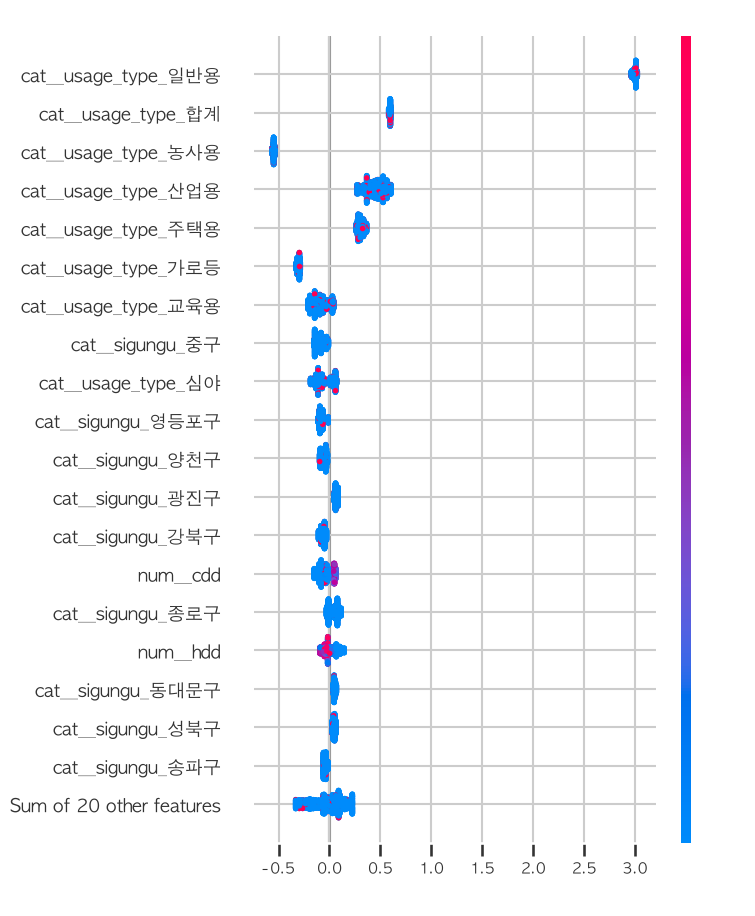

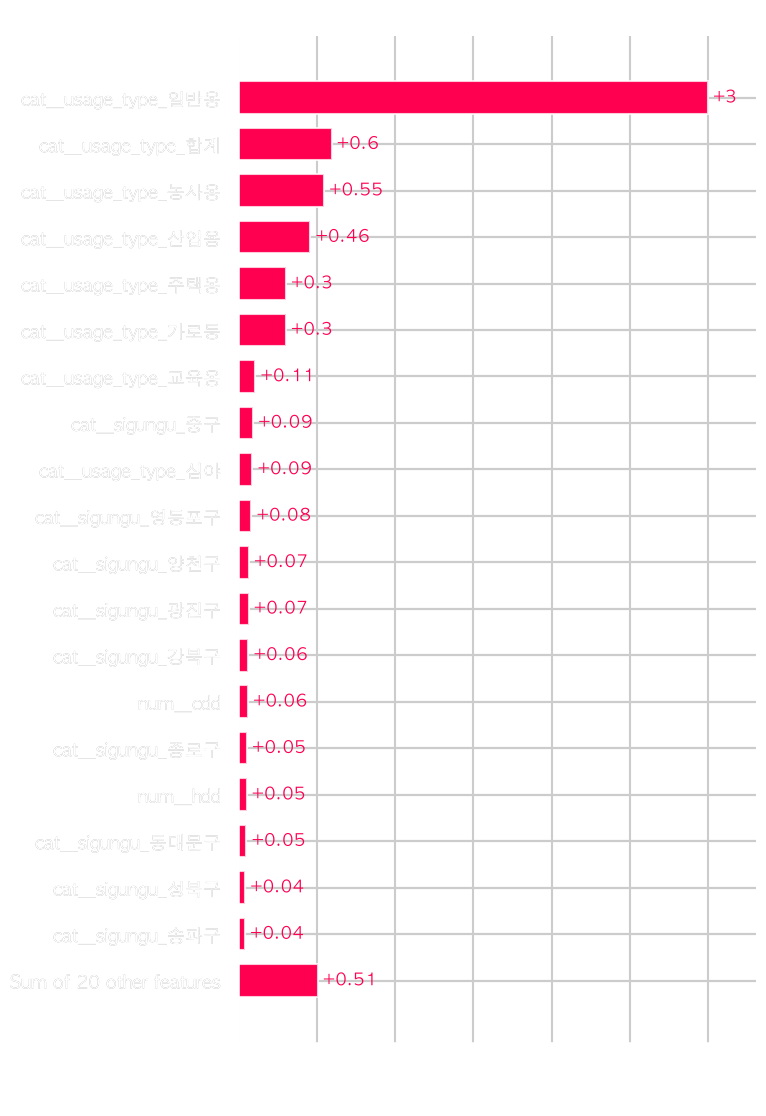

In [247]:
# 필요하면 먼저 설치
# !pip install xgboost shap scikit-learn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap

from xgboost import XGBRegressor
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# =====================
# 1. 데이터 준비
# =====================
data = df.copy()

feature_cols = [
    "sigungu",
    "usage_type",
    "ta_mean",
    "cdd",
    "hdd",
    "thi",
    "oni",
    "reserve_rate"
]

target_col = "usage_ratio"

data = data[["year", "month"] + feature_cols + [target_col]].dropna()

# 시계열 정렬
data["date"] = pd.to_datetime(
    data["year"].astype(str) + "-" +
    data["month"].astype(str).str.zfill(2) + "-01"
)

data = data.sort_values("date").reset_index(drop=True)

X = data[feature_cols]
y = np.log1p(data[target_col])   # 전력 사용량이 크므로 log 변환

# =====================
# 2. Train / Test 분리
# =====================
split_idx = int(len(data) * 0.8)

X_train = X.iloc[:split_idx]
X_test = X.iloc[split_idx:]

y_train = y.iloc[:split_idx]
y_test = y.iloc[split_idx:]

# =====================
# 3. 전처리
# =====================
cat_features = ["sigungu", "usage_type"]
num_features = [
    "ta_mean",
    "cdd",
    "hdd",
    "thi",
    "oni",
    "reserve_rate"
]

preprocess = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features),
        ("num", "passthrough", num_features)
    ]
)

# =====================
# 4. XGBoost 모델
# =====================
xgb = XGBRegressor(
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

pipe = Pipeline(
    steps=[
        ("preprocess", preprocess),
        ("model", xgb)
    ]
)

# =====================
# 5. 하이퍼파라미터 튜닝
# =====================
param_grid = {
    "model__n_estimators": [300, 500, 800],
    "model__max_depth": [3, 4, 5, 6],
    "model__learning_rate": [0.01, 0.03, 0.05, 0.1],
    "model__subsample": [0.7, 0.8, 0.9, 1.0],
    "model__colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "model__reg_lambda": [1, 3, 5, 10]
}

tscv = TimeSeriesSplit(n_splits=5)

search = RandomizedSearchCV(
    estimator=pipe,
    param_distributions=param_grid,
    n_iter=25,
    scoring="neg_mean_absolute_error",
    cv=tscv,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

search.fit(X_train, y_train)

best_model = search.best_estimator_

print("Best Params:")
print(search.best_params_)

# =====================
# 6. 모델 성능 평가
# =====================
pred_log = best_model.predict(X_test)

y_test_real = np.expm1(y_test)
pred_real = np.expm1(pred_log)

r2 = r2_score(y_test_real, pred_real)
mae = mean_absolute_error(y_test_real, pred_real)
rmse = np.sqrt(mean_squared_error(y_test_real, pred_real))

print(f"R²   : {r2:.3f}")
print(f"MAE  : {mae:,.2f}")
print(f"RMSE : {rmse:,.2f}")

# =====================
# 7. SHAP 분석 준비
# =====================
preprocessor = best_model.named_steps["preprocess"]
model = best_model.named_steps["model"]

X_test_transformed = preprocessor.transform(X_test)

# sparse matrix면 dense로 변환
if hasattr(X_test_transformed, "toarray"):
    X_test_transformed = X_test_transformed.toarray()

feature_names = preprocessor.get_feature_names_out()

# 너무 많으면 샘플링
sample_size = min(3000, X_test_transformed.shape[0])
sample_idx = np.random.choice(
    X_test_transformed.shape[0],
    sample_size,
    replace=False
)

X_shap = X_test_transformed[sample_idx]

# =====================
# 8. SHAP 계산
# =====================
explainer = shap.TreeExplainer(model)

shap_values = explainer.shap_values(X_shap)

shap_exp = shap.Explanation(
    values=shap_values,
    base_values=explainer.expected_value,
    data=X_shap,
    feature_names=feature_names
)

# =====================
# 9. SHAP Beeswarm Plot
# =====================
plt.figure(figsize=(10, 8))

shap.plots.beeswarm(
    shap_exp,
    max_display=20,
    show=False
)

plt.title(
    "SHAP Summary Plot: Power Consumption rate Prediction",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

# =====================
# 10. SHAP Feature Importance Bar Plot
# =====================
plt.figure(figsize=(10, 6))

shap.plots.bar(
    shap_exp,
    max_display=20,
    show=False
)

plt.title(
    "SHAP Feature Importance",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

Fitting 5 folds for each of 25 candidates, totalling 125 fits
Best Params:
{'subsample': 1.0, 'reg_lambda': 5, 'n_estimators': 500, 'max_depth': 6, 'learning_rate': 0.1, 'colsample_bytree': 0.8}

[Train]
R²   : 0.9989
MAE  : 4.45
RMSE : 11.69
MAPE : 75151163714118336.00%

[Test]
R²   : 0.9632
MAE  : 16.04
RMSE : 71.81
MAPE : 6540120634961460.00%


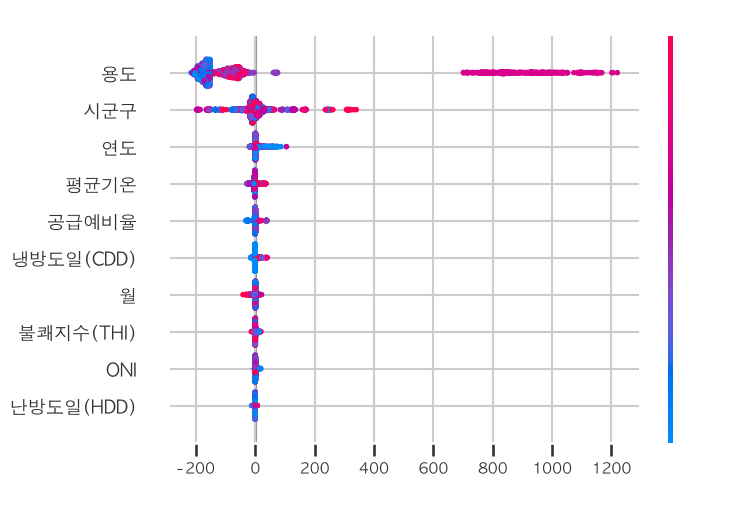

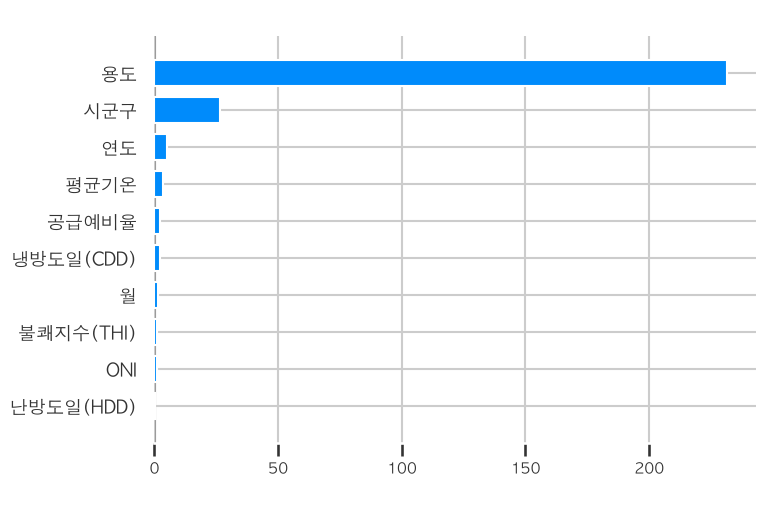

In [251]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap
import xgboost as xgb

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

# =====================
# 1. 데이터 준비
# =====================
data = df.copy()

TARGET_COL = "usage_ratio"

# 시계열 정렬용 date 생성
data["date"] = pd.to_datetime(
    data["year"].astype(str) + "-" +
    data["month"].astype(str).str.zfill(2) + "-01"
)

data = data.sort_values("date").reset_index(drop=True)

# =====================
# 2. Label Encoding
# =====================
le_sigungu = LabelEncoder()
le_usage = LabelEncoder()

data["sigungu_id"] = le_sigungu.fit_transform(data["sigungu"].astype(str))
data["usage_id"] = le_usage.fit_transform(data["usage_type"].astype(str))

# =====================
# 3. 사용할 Feature
# =====================
MODEL_FEATS = [
    "year",
    "month",
    "sigungu_id",
    "usage_id",
    "ta_mean",
    "cdd",
    "hdd",
    "thi",
    "oni",
    "reserve_rate"
]

data = data.dropna(
    subset=MODEL_FEATS + [TARGET_COL]
).copy()

X = data[MODEL_FEATS]
y = data[TARGET_COL]

# =====================
# 4. 시계열 Train / Test 분리
# =====================
train_mask = data["year"] <= 2022

X_train = X[train_mask]
X_test = X[~train_mask]

y_train = y[train_mask]
y_test = y[~train_mask]

# =====================
# 5. XGBoost 모델 튜닝
# =====================
model_xgb = xgb.XGBRegressor(
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1,
    verbosity=0
)

param_grid = {
    "n_estimators": [300, 500, 800],
    "max_depth": [3, 4, 5, 6],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "reg_lambda": [1, 3, 5, 10]
}

tscv = TimeSeriesSplit(n_splits=5)

search = RandomizedSearchCV(
    estimator=model_xgb,
    param_distributions=param_grid,
    n_iter=25,
    scoring="neg_mean_absolute_error",
    cv=tscv,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

search.fit(X_train, y_train)

best_xgb = search.best_estimator_

print("Best Params:")
print(search.best_params_)

# =====================
# 6. 성능 평가
# =====================
pred_train = best_xgb.predict(X_train)
pred_test = best_xgb.predict(X_test)

for label, yt, yp in [
    ("Train", y_train, pred_train),
    ("Test", y_test, pred_test)
]:
    print(f"\n[{label}]")
    print(f"R²   : {r2_score(yt, yp):.4f}")
    print(f"MAE  : {mean_absolute_error(yt, yp):,.2f}")
    print(f"RMSE : {np.sqrt(mean_squared_error(yt, yp)):,.2f}")
    print(f"MAPE : {mean_absolute_percentage_error(yt, yp) * 100:.2f}%")

# =====================
# 7. Feature Label
# =====================
FEAT_LABELS = {
    "year": "연도",
    "month": "월",
    "sigungu_id": "시군구",
    "usage_id": "용도",
    "ta_mean": "평균기온",
    "cdd": "냉방도일(CDD)",
    "hdd": "난방도일(HDD)",
    "thi": "불쾌지수(THI)",
    "oni": "ONI",
    "reserve_rate": "공급예비율"
}

X_train_label = X_train.rename(columns=FEAT_LABELS)
X_test_label = X_test.rename(columns=FEAT_LABELS)

# =====================
# 9. SHAP 분석
# =====================
sample_size = min(3000, X_test_label.shape[0])

X_shap = X_test_label.sample(
    n=sample_size,
    random_state=42
)

explainer = shap.TreeExplainer(best_xgb)

shap_values = explainer.shap_values(X_shap)

# =====================
# 10. SHAP Summary Plot
# =====================
plt.figure(figsize=(10, 7))

shap.summary_plot(
    shap_values,
    X_shap,
    max_display=15,
    show=False
)

plt.title(
    "SHAP Summary Plot: 전력사용량 예측",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

# =====================
# 11. SHAP Bar Plot
# =====================
plt.figure(figsize=(9, 6))

shap.summary_plot(
    shap_values,
    X_shap,
    plot_type="bar",
    max_display=15,
    show=False
)

plt.title(
    "SHAP Feature Importance",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

# 기타

In [176]:
# 시군구별,월별,연도별 평균 전력사용량
gu_power = (
    kepco
    .groupby(["year", "month", "sigungu"], as_index=False)["power_mwh"]
    .mean()
)

In [183]:
max_power_gu = (
    gu_power.loc[
        gu_power.groupby(
            ["year", "month"]
        )["power_mwh"].idxmin()
    ]
    .sort_values(["year", "month"])
    .reset_index(drop=True)
)

# max_power_gu.to_csv(DATA_OUTPUT/"max_power_gu.csv")

max_power_gu['sigungu'].unique()

<StringArray>
['강북구', '중랑구', '서대문구', '도봉구', '강남구']
Length: 5, dtype: str

In [184]:
max_power_gu

,year,month,sigungu,power_mwh
0,2005,1,강북구,22947.578947
1,2005,2,강북구,22399.289474
2,2005,3,강북구,20371.236842
3,2005,4,강북구,20466.894737
4,2005,5,강북구,18969.236842
...,...,...,...,...
251,2025,12,도봉구,23163.105053
252,2026,1,도봉구,27115.492579
253,2026,2,도봉구,27158.080789
254,2026,3,도봉구,20959.552842
